# Bayesian BLP: Structural Demand Estimation on Aggregate Market Shares


In [48]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm, qmc

from pymc_marketing.customer_choice import BayesianBLP, generate_blp_panel

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = 'retina'

Discrete choice modelling is derived from the idea that choices are determined by subjective estimates of utility. That's a useful lens when we have information about the individual actors who are making choices in the market. It's a frustrating gap in the data when we only have aggregate sales statistics. How can we infer latent utility from market wide patterns? Is this not simply a case of the ecological fallacy?

Let's assume we have two markets only: 

- Market A: 40% share for sugary cereal, average income $30k
- Market B: 60% share for sugary cereal, average income $50k

If we try and naively disaggregate we might conclude that: "Higher income causes people to buy more sugary cereal." In reality, it's perfectly possible that within each market lower-income households tend to buy more sugary cereal, but that market B happens to have a younger population that drives higher incomes and sugary cereal consumption. There are at least two dimensions to this problem worth calling out: (1) this is a kind of selection effect problem where Markets is a confounder, and the aggregation over heterogenous markets biases our conclusions and (2) the extremity of the difference between the global view and the within market view is unobserved. We could have an extreme Simpson's paradox style reversal, or just a muted effect. This mistaken generalisation - moving from aggregate metrics to unit-level claims - is called the ecological fallacy.

### BLP's Big Idea

How then can we move from aggregate data to sensible utility based implications? In particular, how can we think about the effect of price movements on demand? We must assume that there are different degrees of price sensitivity latent in each market. If we can make this assumption, the next natural question is what is the shape and contours of the preference distribution implied by the observed data. BLP models don't try to reconstruct individual attributes from aggregate data. Instead, they integrate over the possible distribution of preferences and ask: "What distribution of individual preferences would generate these observed aggregate shares? This is a canonical Bayesian question. 

#### Halton Draws, Scrambling and Taste Profiles

Practically, we need to think about how to encode the preference distribution, so which unit-level taste profiles best predict market level shares. To describe the distribution of individual taste profiles we characterise them as weightings of the attributes or characteristics of the observed goods. Here we might think of them as combinations of utility accorded to cereals based on different weightings of the price, texture and quality. These three attributes form a cube. We can't realistically survey all weightings of the combinations of weights across the 3-dimensional space, but we might cleverly construct combinations that represent extreme boundary states and compromised middle grounds. This kind of construction is achieved using the method of Halton draws. 

In [2]:
# --- Generate Halton draws ---
sampler_halton = qmc.Halton(d=3, scramble=True)
u = sampler_halton.random(100)

# Avoid infinities in inverse CDF
eps = np.finfo(np.float64).tiny
u = np.clip(u, eps, 1.0 - eps)

# Transform to Gaussian
z = norm.ppf(u)

# IID uniform for comparison
rand = np.random.rand(100, 3)

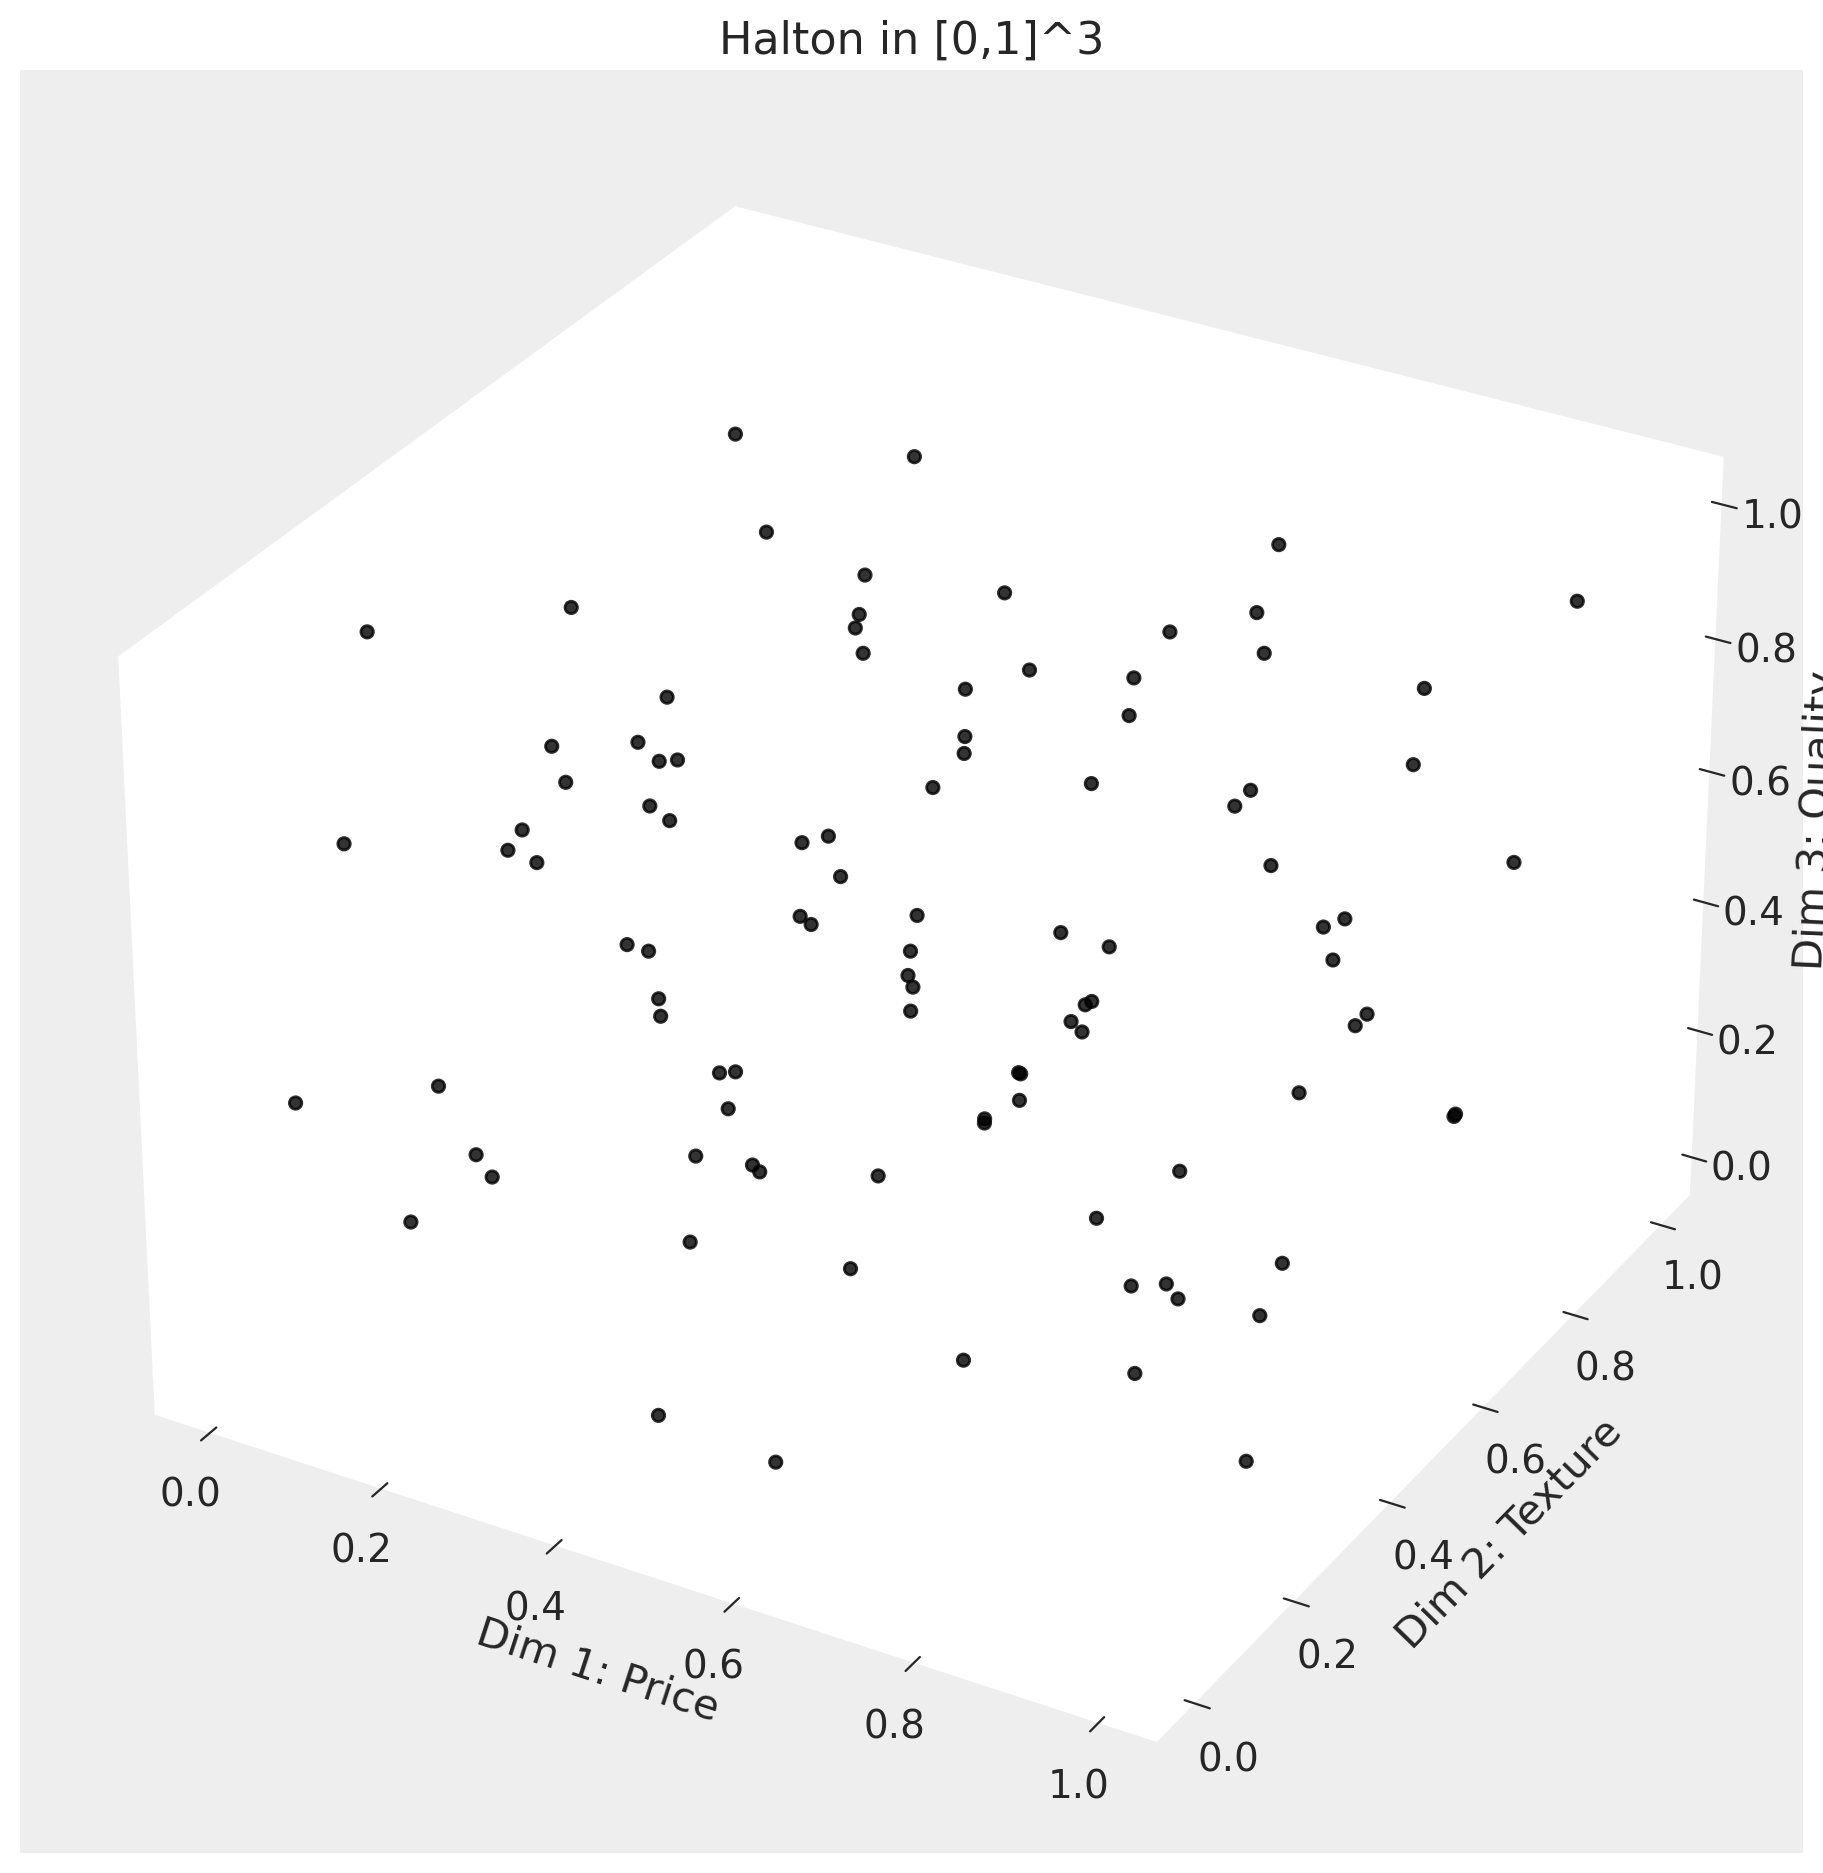

In [3]:
# --- Create figure layout ---
fig = plt.figure(figsize=(9, 14))
ax = fig.add_subplot(projection="3d")

# Scatter (make it pop)
ax.scatter(u[:, 0], u[:, 1], u[:, 2], s=20, color="black", alpha=0.8)

# White panes
ax.xaxis.set_pane_color((1, 1, 1, 1))
ax.yaxis.set_pane_color((1, 1, 1, 1))
ax.zaxis.set_pane_color((1, 1, 1, 1))

# Light grid
ax.grid(True, color="0.85", linewidth=0.8)

# Axis labels
ax.set_xlabel("Dim 1: Price")
ax.set_ylabel("Dim 2: Texture")
ax.set_zlabel("Dim 3: Quality")
ax.set_title("Halton in [0,1]^3")

plt.show()

We compare the coverage of the combinatorial space to uniform sampling. This shows why the Halton construction gives a good coverage of the possible latent taste profiles. This property of sufficient coverage is what allows us use the Halton draws in our Bayesian inference. We must assess over the taste profiles to see which is the most plausible conditional on the observed aggregate shares. 

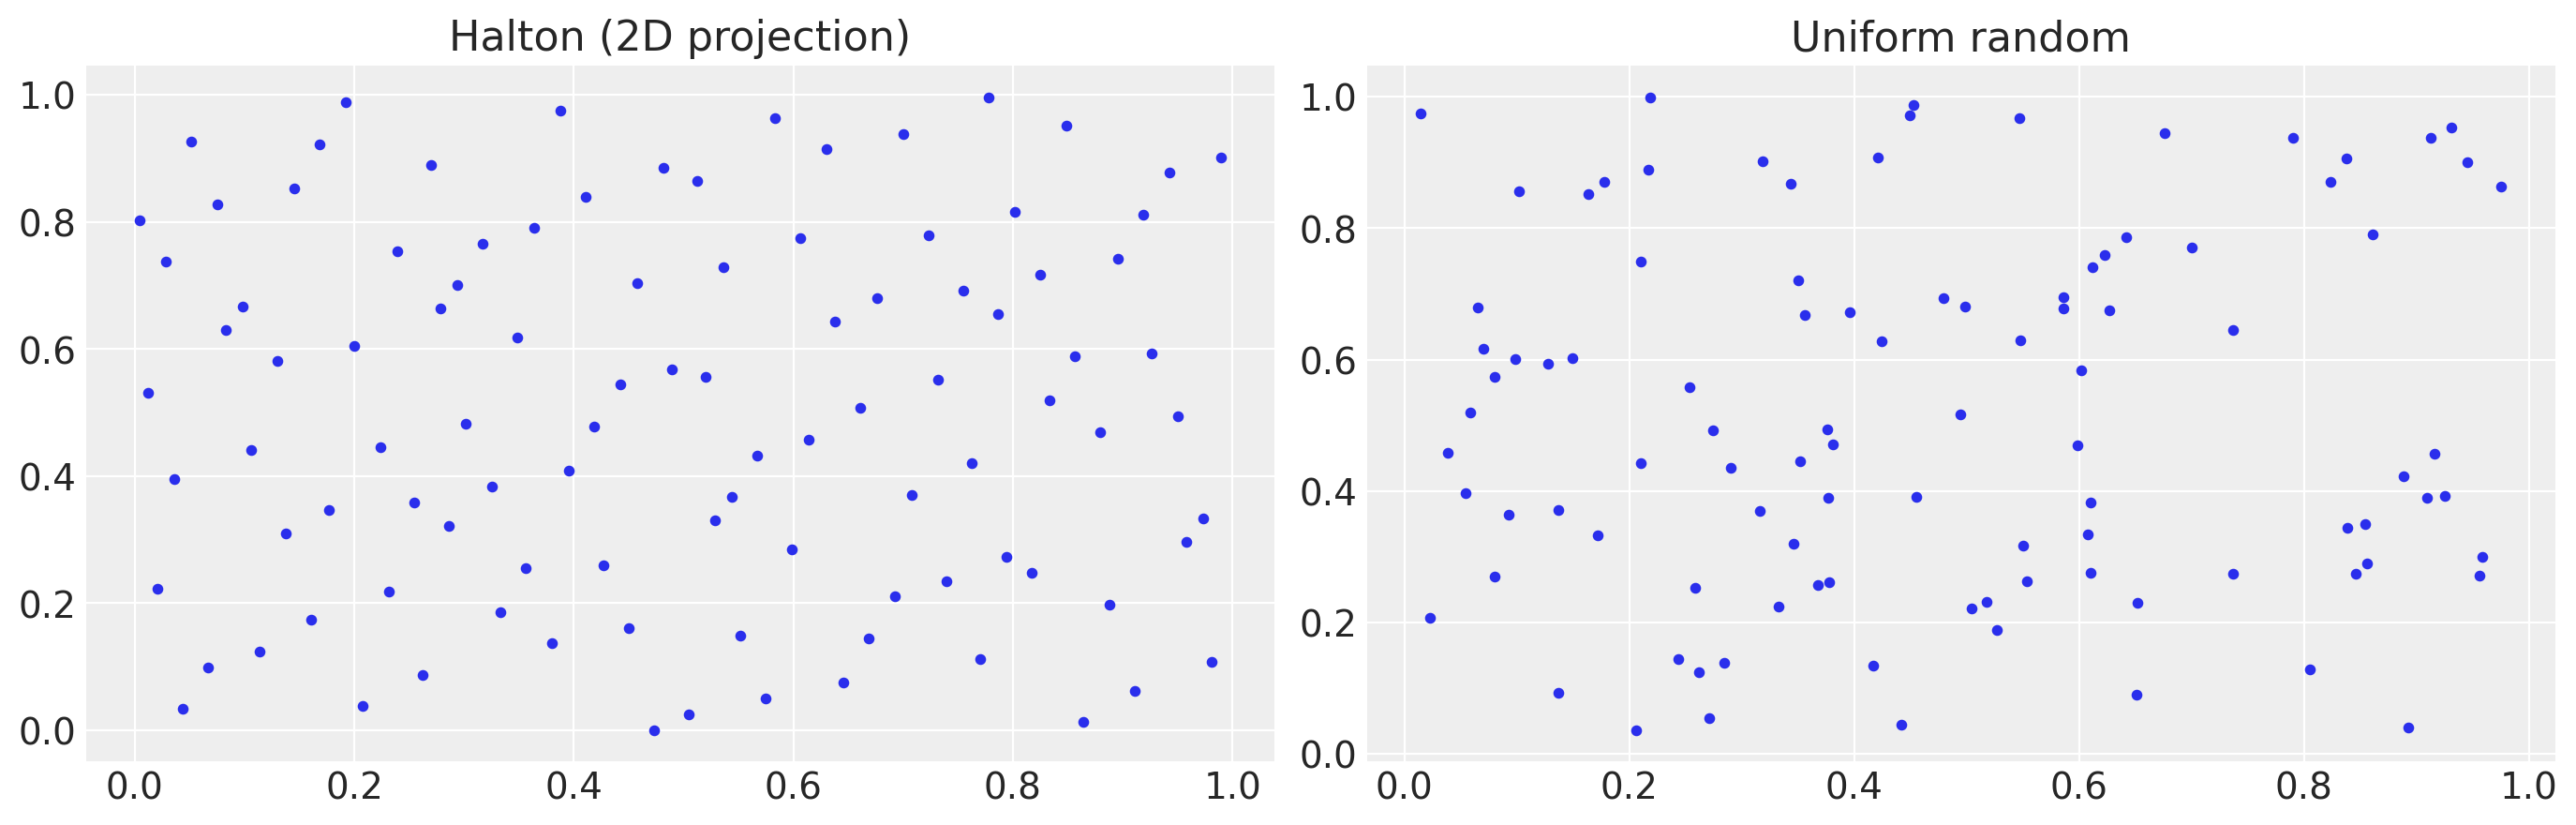

In [4]:
fig = plt.figure(figsize=(20, 8))

# ========== 3. Comparison with random ==========
ax4 = fig.add_subplot(231)
ax4.scatter(u[:, 0], u[:, 1], s=10)
ax4.set_title("Halton (2D projection)")

ax5 = fig.add_subplot(232)
ax5.scatter(rand[:, 0], rand[:, 1], s=10)
ax5.set_title("Uniform random");

The Halton construction is better at filling the space than random sampling, which can lead to more accurate estimates with fewer draws. This is especially important in BLP, where we need to integrate over the distribution of consumer tastes. With this approximation in hand, we can run Bayesian inference across the fixed Halton draws in our model architecture confident that the model can be calibrated towards the more plausible taste profiles in the distribution of taste profiles determined by the cube of product attributes.

We'll defer further discussion of the Halton construction only to say that it enters the utility equation that determines market share. 

$$
\hat{s}_{jm} =
\int_{\mathbb{R}^D}
\frac{\exp(\delta_{jm} + \mu_{ijm})}
     {1 + \sum_{k=1}^{J} \exp(\delta_{km} + \mu_{ikm})}
\; dF(\bm{\nu}_i; \mathbf{0}, \mathbf{I}_D)
$$

The components of market share are the mean utility and individual deviation are:

$$
\delta_{jm} = \alpha_{r(m)} \, p_{jm} + \mathbf{x}_{jm}'\bm{\beta}_{r(m)} + \xi_{jm}
$$

$$
\mu_{ijm} = \sum_{d=1}^{D} \sigma_d \cdot \nu_{id} \cdot z_{jmd}
$$

The $\delta_{jm}$ term is a function of price and other observed attributes of the products in the market, where the parameters $\alpha$ and $\beta$ determine how they are weighted on average. This is the decomposition we are seeking to achieve. We want to model market aggregate shares as a function latent taste profiles. 


### When to use this model

PyMC-Marketing ships three discrete-choice model families. Choosing the right one avoids both under-fitting and unnecessary complexity:

| Model | Data shape | What it answers |
|---|---|---|
| **MNL / MixedLogit** | Individual choice occasions | Who chose what, and why? |
| **MVITS** | Aggregate share time series | What happened when brand X launched? |
| **BayesianBLP** *(this notebook)* | Aggregate share panels | What would happen if I changed price? |

**BayesianBLP** is a *structural* random-coefficients logit on aggregate shares — the Bayesian reformulation of Berry, Levinsohn & Pakes (1995) following Jiang, Manchanda & Rossi (2009). It is the right tool when:

- You only have **aggregate market shares** (not individual transactions).
- You need structurally grounded **cross-price substitution patterns**.
- Prices may be **endogenous** (set by firms who observe unobserved demand shocks)
  and you have **cost or rival-characteristic instruments** to correct for the bias.
- You want **full posterior uncertainty** on elasticities and counterfactual shares,
  with correct propagation through the structural demand model.

The Bayesian formulation replaces the classical BLP contraction mapping + GMM with a joint posterior over preference parameters and the latent demand shocks ξ_jt. This makes hierarchical pooling across regions cheap and returns honest credible intervals even under weak instruments.


## 1. Synthetic data: a BLP-style aggregate share panel

We use `generate_blp_panel` to create a synthetic panel with known true parameters. The data-generating process produces a joint `(η_jt, ξ̃_jt)` shock so that prices are **endogenous** — naive estimation without instruments will bias the price coefficient toward zero.

The returned DataFrame is in long format: one row per (market, product), with the outside good as a special row labelled `'outside'`. The `truth` dictionary records the DGP parameters we will try to recover.

**Market semantics.** A BLP "market" is a `(region, period)` cell — the unit at which shares and prices are observed. The model treats markets as exchangeable unless you tell it otherwise: pass `time_col="period"` to `BayesianBLP` to expose `period` as a first-class coordinate. Then `counterfactual_shares` and `elasticities` accept `periods=` / `regions=` coord-label arguments so you can phrase questions like "raise prod_0 price by 10% in periods 10–20" directly, rather than reverse-engineering a flat market index. This notebook turns that on at construction so the time-targeted counterfactual section near the end just works.


In [38]:
df, truth = generate_blp_panel(
    T=40,  # markets (think: 40 weeks)
    J=3,  # inside products
    K=2,  # product characteristics
    L=2,  # instruments per product
    true_alpha=-2.0,
    true_beta=np.array([0.8, 1.2]),
    sigma_alpha=0.5,  # std of consumer price heterogeneity
    instrument_strength=0.7,  # first-stage R² ≈ 0.49
    price_xi_corr=0.6,  # endogeneity severity
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=42,
    return_truth=True,
)

print(
    f"Panel: {df['market'].nunique()} markets × {len(truth['characteristic_cols'])} "
    f"characteristics + {len(truth['instrument_cols'])} instruments"
)
print(f"True alpha (price):  {truth['alpha']:.3f}")
print(f"True beta:           {truth['beta']}")
print(f"True sigma_alpha:    {truth['sigma_alpha']:.3f}")
print(f"Outside share mean:  {df[df['product'] == 'outside']['share'].mean():.3f}")

Panel: 40 markets × 2 characteristics + 2 instruments
True alpha (price):  -2.000
True beta:           [0.8 1.2]
True sigma_alpha:    0.500
Outside share mean:  0.667


In [39]:
df.head(8)

,region,market,period,product,share,n,price,x_0,x_1,z_0,z_1
0,r0,0,0,outside,0.9315,4000,0.000000,0.0,0.000000,0.000000,0.000000
1,r0,0,0,prod_0,0.0005,4000,4.124200,0.0,-0.863345,0.006339,2.597674
2,r0,0,0,prod_1,0.0380,4000,1.210960,0.0,-0.147529,0.223080,1.433215
3,r0,0,0,prod_2,0.0300,4000,1.987674,0.0,-0.152523,0.091520,0.580777
4,r0,1,1,outside,0.5560,4000,0.000000,0.0,0.000000,0.000000,0.000000
5,r0,1,1,prod_0,0.3985,4000,0.929217,1.0,0.383394,-0.056783,-0.170408
6,r0,1,1,prod_1,0.0445,4000,2.298272,1.0,0.999824,-0.779482,0.430301
7,r0,1,1,prod_2,0.0010,4000,3.006346,0.0,-1.058536,-0.851537,0.665585


## 2. Model specification and prior predictive check

We instantiate `BayesianBLP` with:
- `random_coef_on=['price']` — consumer-level price heterogeneity `α_i = α_r + σ_α · ν_i`
- `instruments=truth['instrument_cols']` — enables the price-endogeneity correction
- `n_mc_draws=100` — Owen-scrambled Halton draws for the share integral. This parameter can be tweaked to get greater coverage of possible tast profiles. 

A prior predictive check confirms that the priors put mass on shares that are plausible for scanner data (no pathological predictions).


In [7]:
model = BayesianBLP(
    market_data=df,
    characteristics=truth["characteristic_cols"],
    instruments=truth["instrument_cols"],
    random_coef_on=["price"],
    time_col="period",
    n_mc_draws=100,
    random_seed=0,
)
model

Sampling: [alpha, beta, gamma_xi_eta, log_share_ratio, omega_xi, pi_0, pi_z, price_obs, sigma_eta, sigma_random, sigma_xi_j, xi_j_raw, xi_tilde_raw]


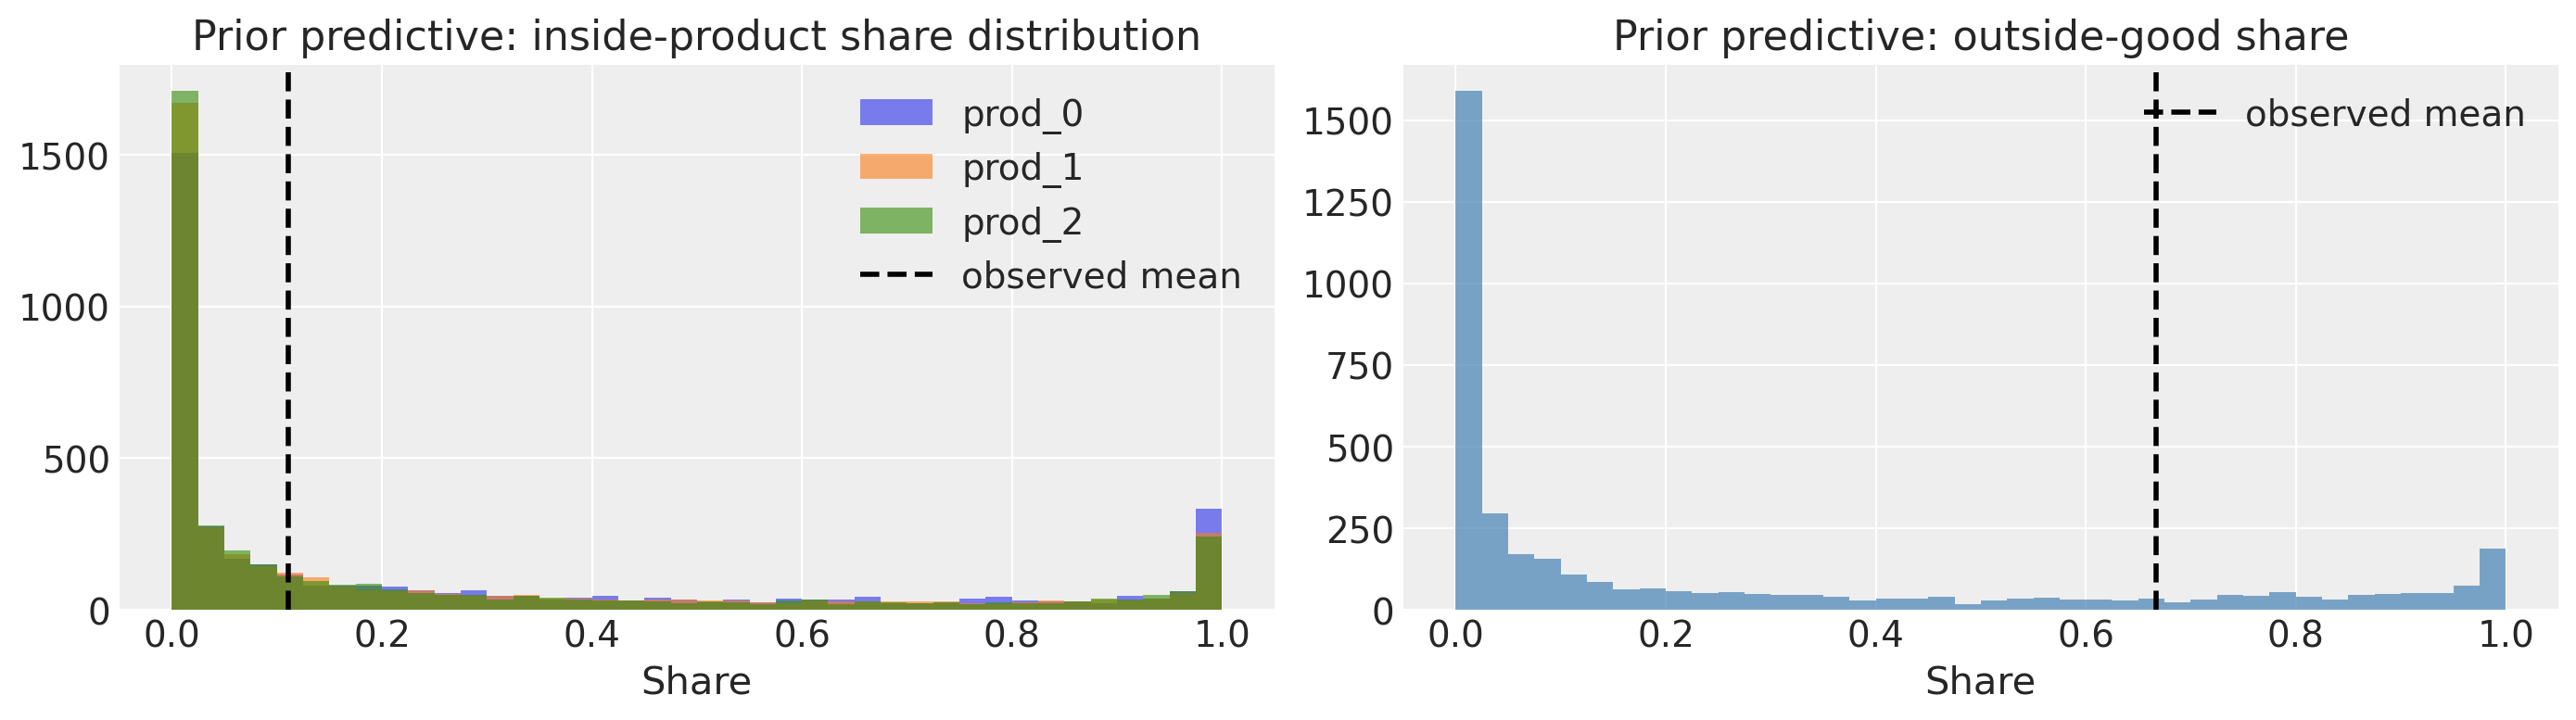

Shares sum to 1: True


In [8]:
prior = model.sample_prior_predictive(samples=100)

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Inside shares
s_in_prior = prior.prior["s_inside"].values.reshape(-1, model._M, model._J)
for j, pname in enumerate(model._inside_products):
    axs[0].hist(s_in_prior[:, :, j].ravel(), bins=40, alpha=0.6, label=pname)
axs[0].axvline(
    df[df["product"] != "outside"].groupby("product")["share"].mean().mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[0].set_title("Prior predictive: inside-product share distribution")
axs[0].set_xlabel("Share")
axs[0].legend()

# Outside share
s_out_prior = prior.prior["s_outside"].values.ravel()
axs[1].hist(s_out_prior, bins=40, color="steelblue", alpha=0.7)
axs[1].axvline(
    df[df["product"] == "outside"]["share"].mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[1].set_title("Prior predictive: outside-good share")
axs[1].set_xlabel("Share")
axs[1].legend()

plt.tight_layout()
plt.show()
print(
    f"Shares sum to 1: "
    f"{np.allclose(s_in_prior.sum(axis=-1) + prior.prior['s_outside'].values[0], 1.0)}"
)

## 3. Fitting the model with instruments

The model is fit with the `nutpie` backend. We use deliberately small draw counts here for speed — in practice use `draws=2000, tune=2000, chains=4`

In [40]:
_FIT_KWARGS = dict(
    nuts_sampler="nutpie",
    draws=1000,
    tune=1000,
    chains=4,
    progressbar=True,
    random_seed=0,
)

model.fit(**_FIT_KWARGS)
n_div = int(model.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div}")  # should be 0

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.08,127
,2000,0,0.08,63
,2000,0,0.08,127
,2000,0,0.10,63


Divergences: 0


## 4. Posterior summary and parameter recovery

We check whether the fitted posterior recovers the known DGP parameters.
The key structural parameters are:

- `alpha_r` — the (mean-field) price coefficient; should be negative and close to
  the true value
- `beta_r` — characteristic utility weights; should recover `true_beta`
- `sigma_random` — standard deviation of consumer-level price heterogeneity
- `rho_price_xi` — the endogeneity correlation (how much ξ co-moves with price
  residuals); a positive value confirms that price is endogenous


In [41]:
key_vars = ["alpha_r", "beta_r", "sigma_random", "rho_price_xi"]
az.summary(model.idata, var_names=key_vars, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_r[all],-2.01,0.07,-2.14,-1.88,0.00,0.0,364.74,771.40,1.01
"beta_r[all, x_0]",0.79,0.05,0.69,0.89,0.00,0.0,462.77,829.45,1.02
"beta_r[all, x_1]",1.19,0.03,1.13,1.24,0.00,0.0,588.89,1247.13,1.00
sigma_random[price],0.54,0.05,0.46,0.63,0.00,0.0,587.54,1301.26,1.00
rho_price_xi,0.59,0.11,0.39,0.78,0.01,0.0,401.14,1024.68,1.01


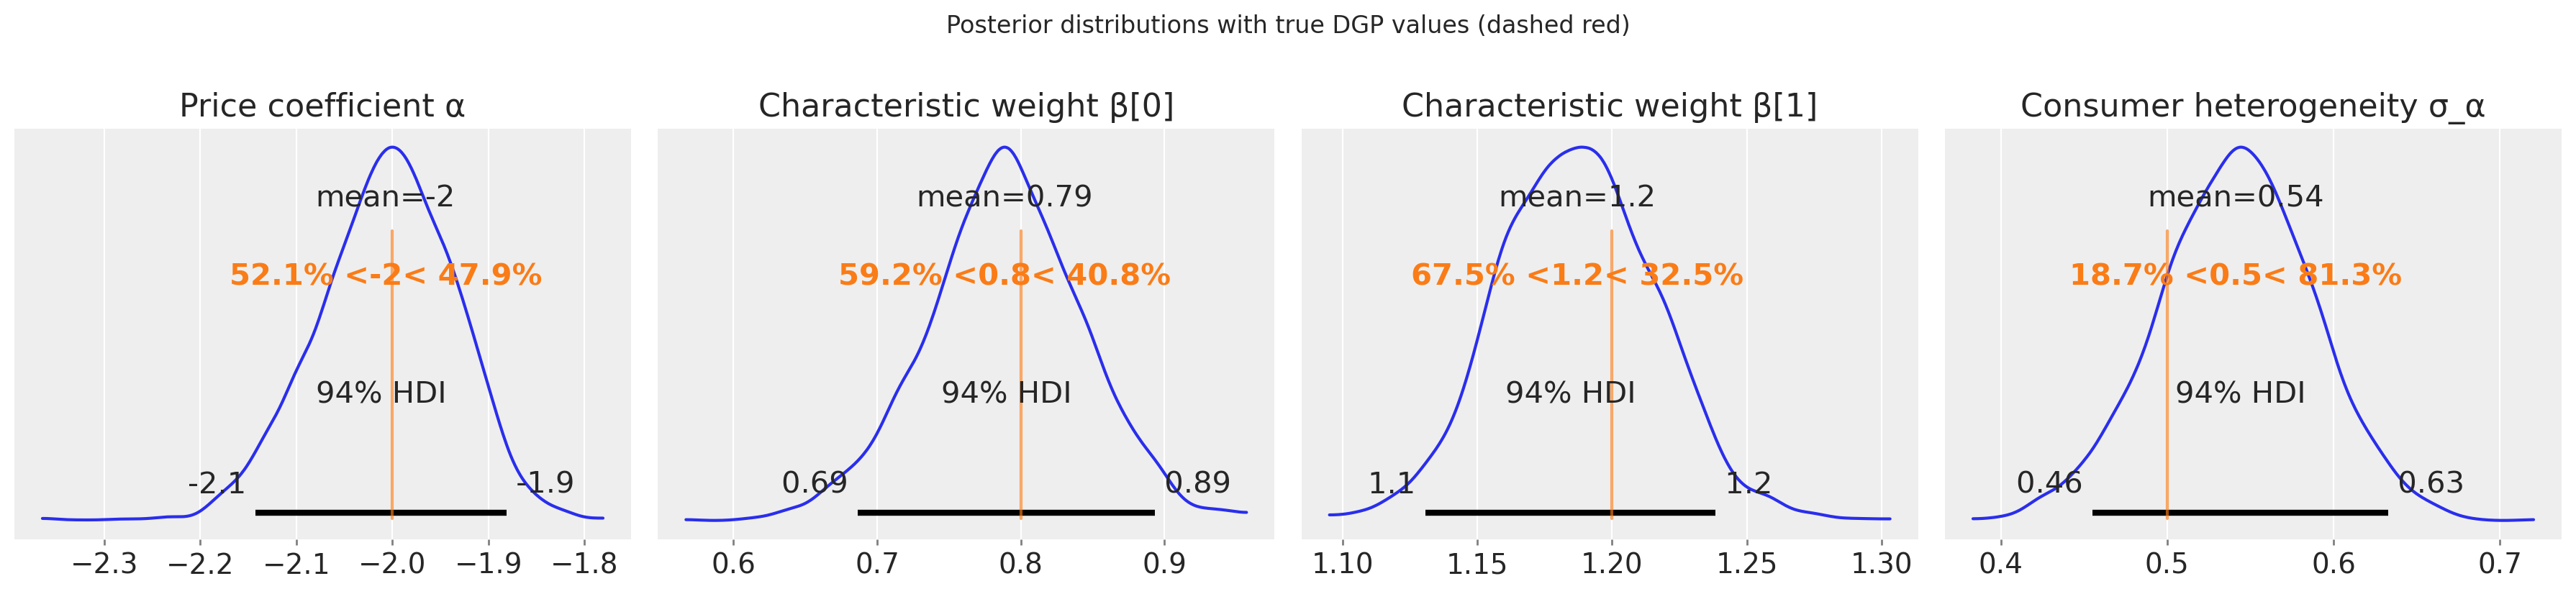

In [42]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4))

truth_vals = {
    "alpha_r": truth["alpha"],
    "beta_r[0]": truth["beta"][0],
    "beta_r[1]": truth["beta"][1],
    "sigma_random[0]": truth["sigma_alpha"],
}

ax = axs[0]
az.plot_posterior(model.idata, var_names=["alpha_r"], ref_val=truth["alpha"], ax=ax)
ax.set_title("Price coefficient α")

beta_post = model.idata.posterior["beta_r"].values.reshape(
    -1, model._J if model.region_col else 1, 2
)
for k, ax in zip(range(2), axs[1:3], strict=True):
    az.plot_posterior(
        model.idata,
        var_names=["beta_r"],
        coords={"characteristic": truth["characteristic_cols"][k]},
        ref_val=float(truth["beta"][k]),
        ax=ax,
    )
    ax.set_title(f"Characteristic weight β[{k}]")

az.plot_posterior(
    model.idata,
    var_names=["sigma_random"],
    coords={"random_coef": "price"},
    ref_val=truth["sigma_alpha"],
    ax=axs[3],
)
axs[3].set_title("Consumer heterogeneity σ_α")

plt.suptitle("Posterior distributions with true DGP values (dashed red)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Endogeneity correction: IV vs. no-IV

The headline feature of BLP is the endogeneity correction. When prices are set by firms that observe unobserved demand shocks ξ_jt, naively regressing shares on prices overstates willingness-to-pay (biases α toward zero). We fit a second model *without* instruments to illustrate the bias. With `price_xi_corr=0.6`, the no-IV estimator is expected to recover an alpha pulled towards 0. 


In [43]:
# Fit without instruments (endogeneity bias expected)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_noiv = BayesianBLP(
        market_data=df,
        characteristics=truth["characteristic_cols"],
        instruments=None,  # no IV
        random_coef_on=["price"],
        n_mc_draws=100,
        random_seed=0,
    )
    model_noiv.fit(**_FIT_KWARGS)

iv_alpha = float(model.idata.posterior["alpha_r"].values.mean())
noiv_alpha = float(model_noiv.idata.posterior["alpha_r"].values.mean())

print(f"True alpha:            {truth['alpha']:+.3f}")
print(
    f"IV posterior mean:     {iv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - iv_alpha):.3f})"
)
print(
    f"no-IV posterior mean:  {noiv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - noiv_alpha):.3f})"
)
print()
if abs(truth["alpha"] - noiv_alpha) > abs(truth["alpha"] - iv_alpha):
    print("✓  IV fit is closer to truth, endogeneity correction is working.")
else:
    print("✗  Unexpected — check the seed / DGP.")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.09,31
,2000,0,0.09,127
,2000,0,0.09,127
,2000,0,0.09,31


True alpha:            -2.000
IV posterior mean:     -2.007  (bias 0.007)
no-IV posterior mean:  -1.908  (bias 0.092)

✓  IV fit is closer to truth, endogeneity correction is working.


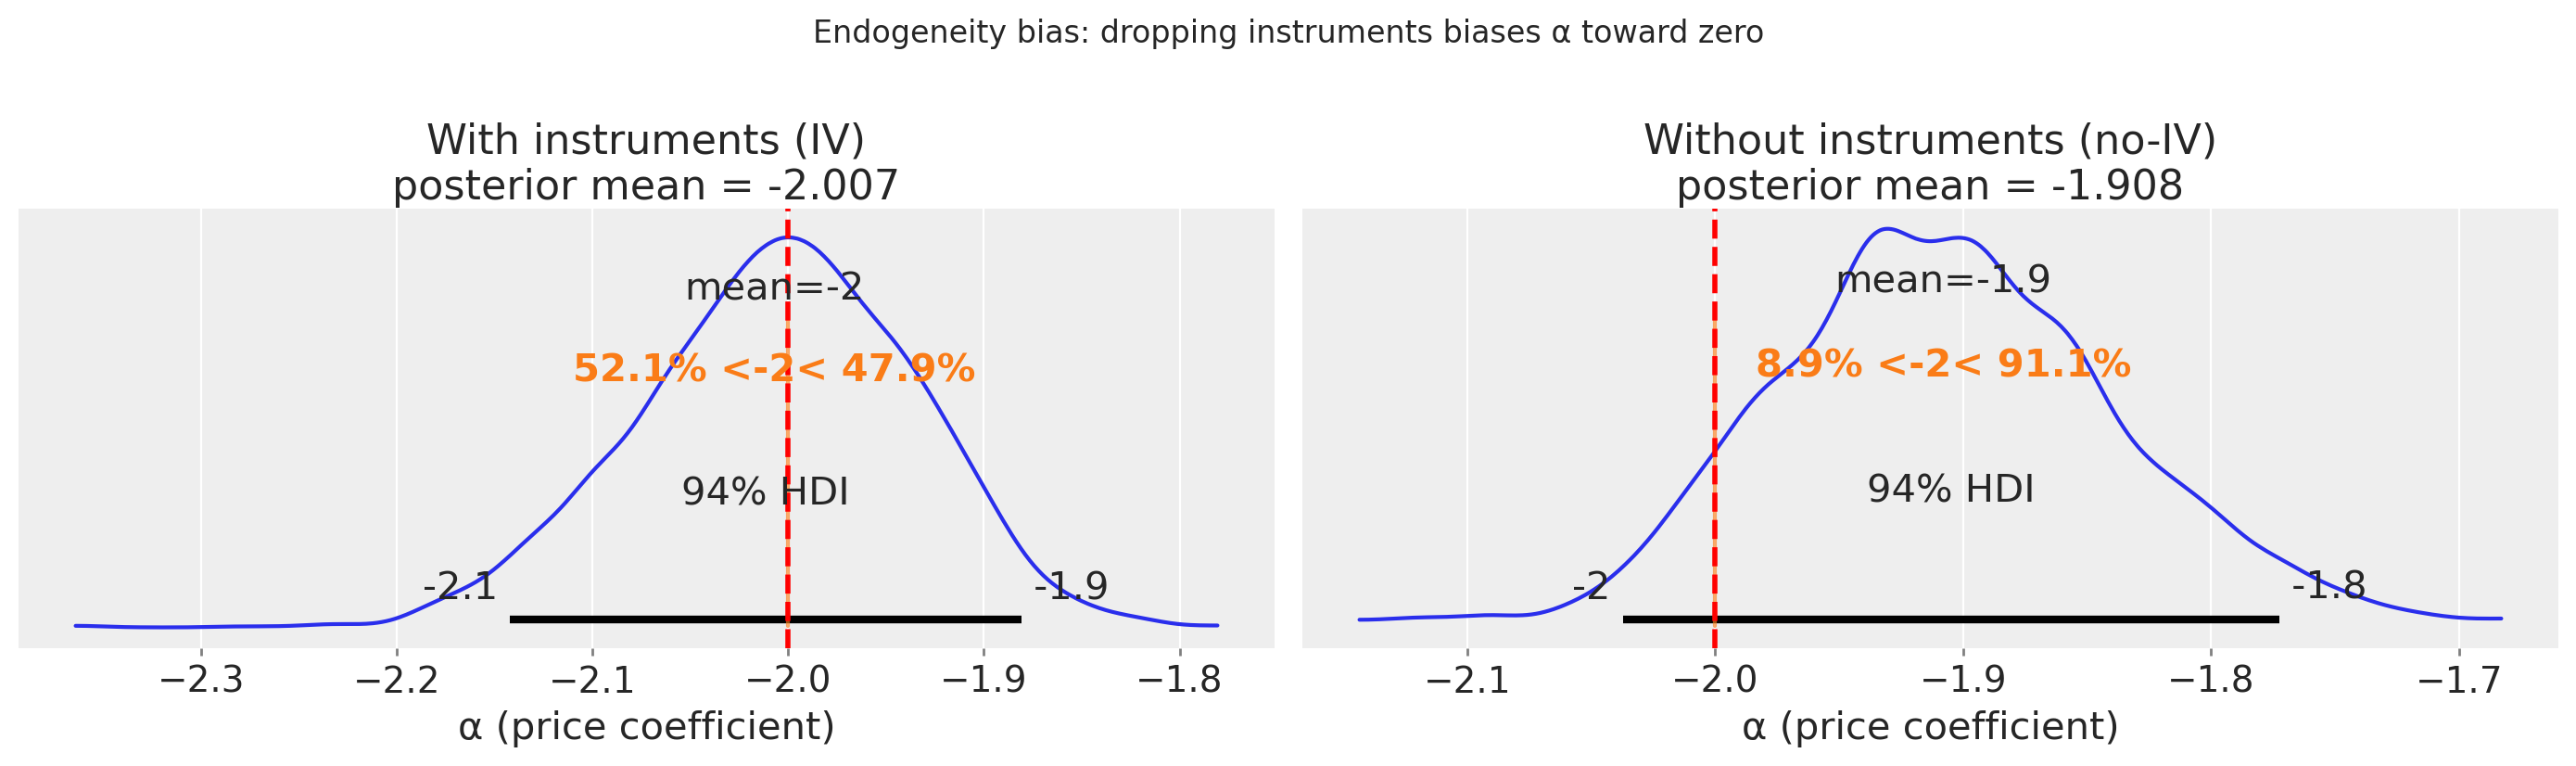

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

az.plot_posterior(
    model.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[0],
)
axs[0].set_title(f"With instruments (IV)\nposterior mean = {iv_alpha:.3f}")

az.plot_posterior(
    model_noiv.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[1],
)
axs[1].set_title(f"Without instruments (no-IV)\nposterior mean = {noiv_alpha:.3f}")

for ax in axs:
    ax.axvline(truth["alpha"], color="red", lw=2, ls="--", label="truth")
    ax.set_xlabel("α (price coefficient)")

plt.suptitle("Endogeneity bias: dropping instruments biases α toward zero", y=1.02)
plt.tight_layout()
plt.show()

## 6. Price elasticities

The closed-form mixed-logit elasticity is

$$
\varepsilon_{jk}(m) = \frac{p_{km}}{s_{jm}} \cdot \frac{1}{R}
\sum_r \alpha_{ir}(m) \cdot s_{jmr} \bigl(\delta_{jk} - s_{kmr}\bigr)
$$

where the integral over consumer types uses the same Halton draws as the likelihood (essentially free). Own-price elasticities are on the diagonal(negative), cross-price elasticities are off-diagonal (positive for substitutes). `elasticities(at='mean')` returns the posterior-mean elasticity matrix; `at='samples'` returns the full posterior distribution.


In [45]:
elast = model.elasticities(at="mean", n_samples=300)
print("Elasticity array shape:", elast.shape)  # (market, share, price)
print("Dims:", elast.dims)

Elasticity array shape: (40, 3, 3)
Dims: ('market', 'share', 'price')


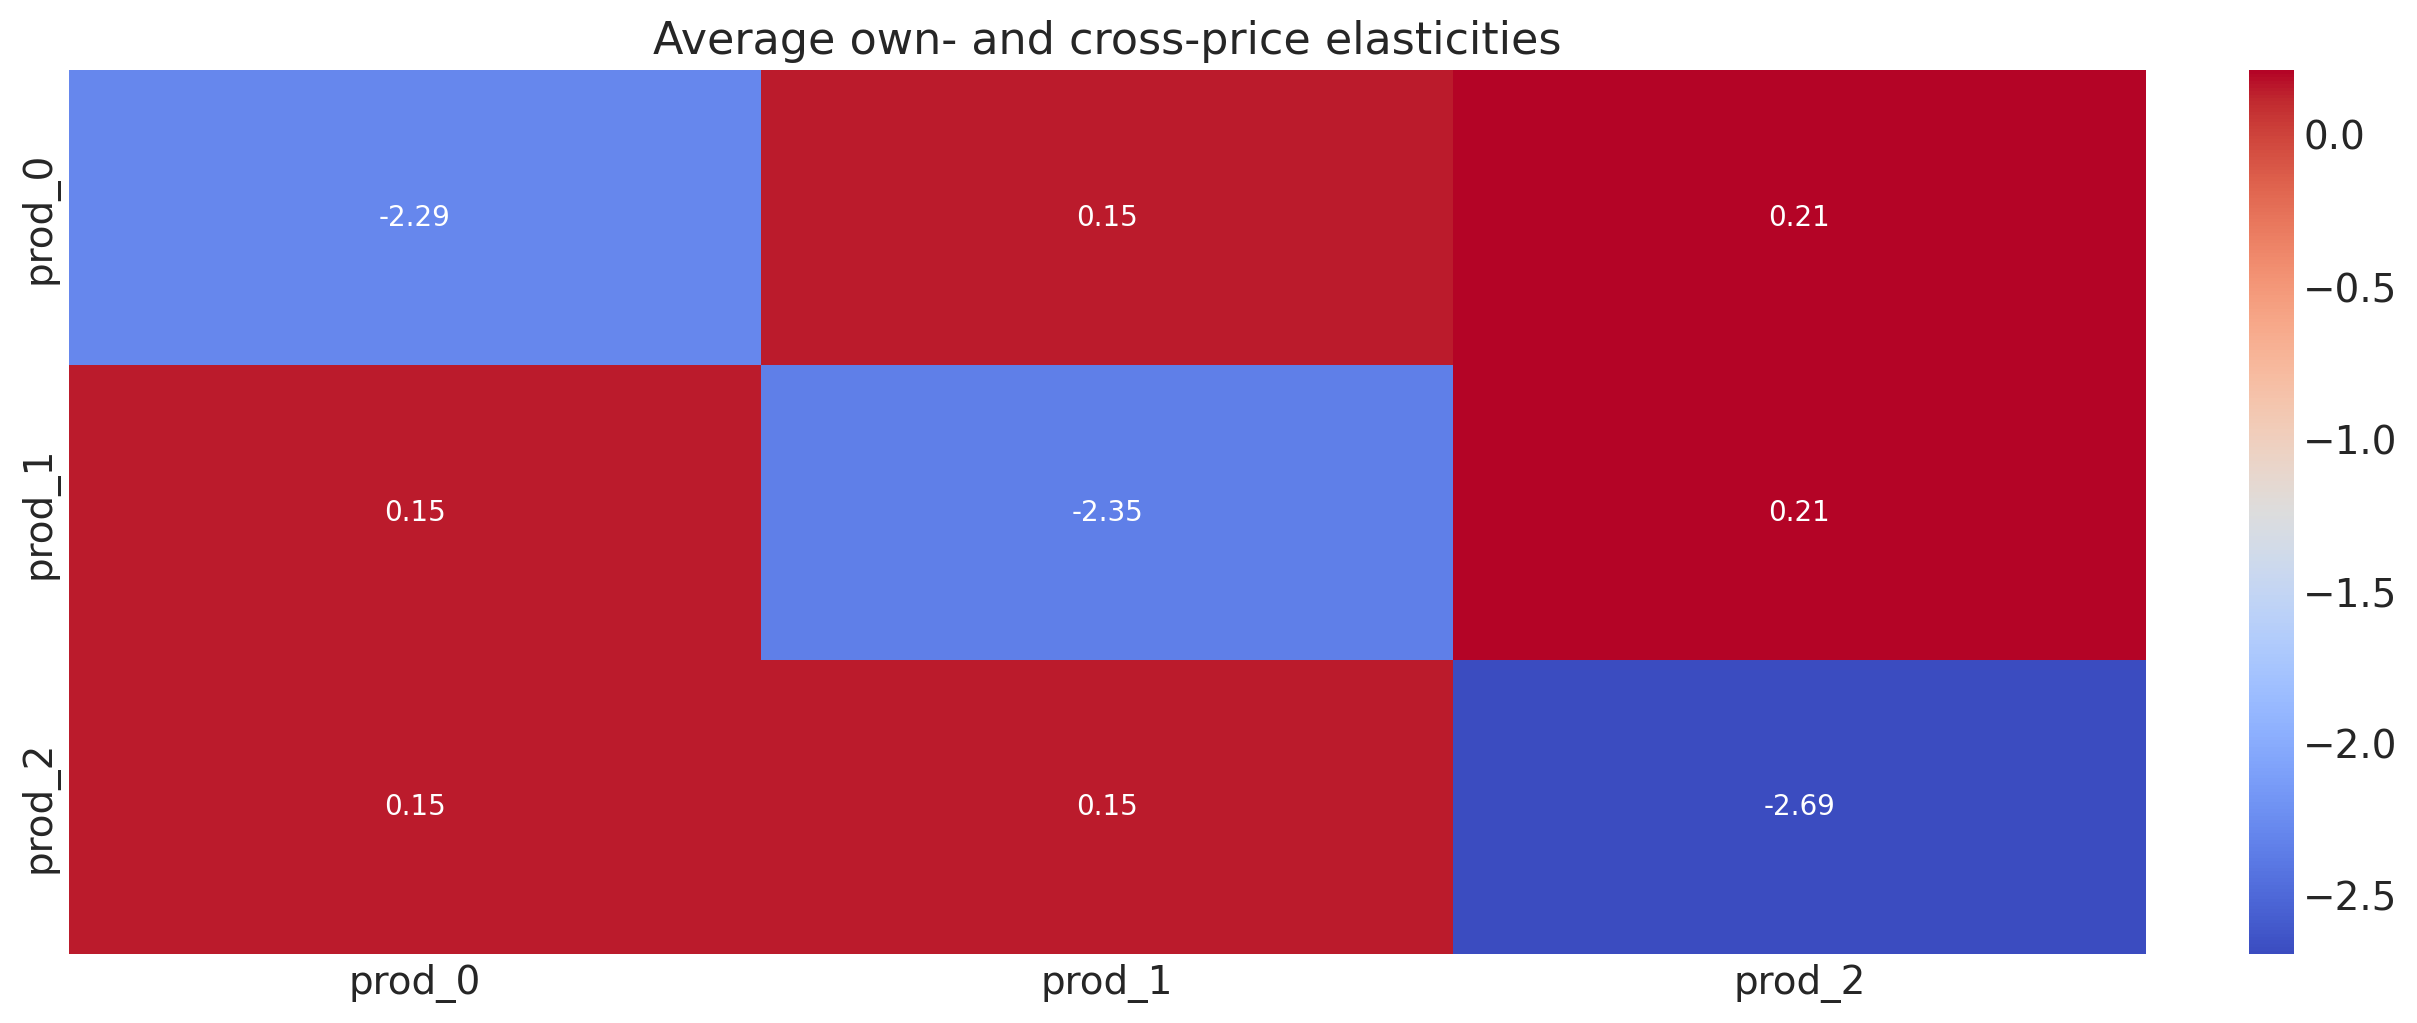

In [50]:
# Average across markets
elast_mean = elast.mean(dim="market").values  # (J, J)

sns.heatmap(
    elast_mean,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=model._inside_products,
    yticklabels=model._inside_products,
)
plt.title("Average own- and cross-price elasticities");

### Posterior distribution of the market-averaged own elasticity

The heatmap above shows the posterior *mean* elasticity per cell. To see the **uncertainty** around each product's own-price elasticity, we average across markets *per posterior sample* and plot the resulting one-dimensional posterior:

$$
\bar{\varepsilon}_{jj}(s) = \frac{1}{M} \sum_m \varepsilon_{jj}(m, s)
$$

This produces one value per posterior sample per product — the *typical* own-price elasticity for that SKU across the panel — yielding a clean unimodal posterior whose width reflects joint uncertainty in `α_r`, `σ_random`, and `ξ`.

A naïve flatten of `(sample × market)` into a single density would plot a multi-modal mixture, with one mode per market, and obscure the genuine posterior uncertainty.


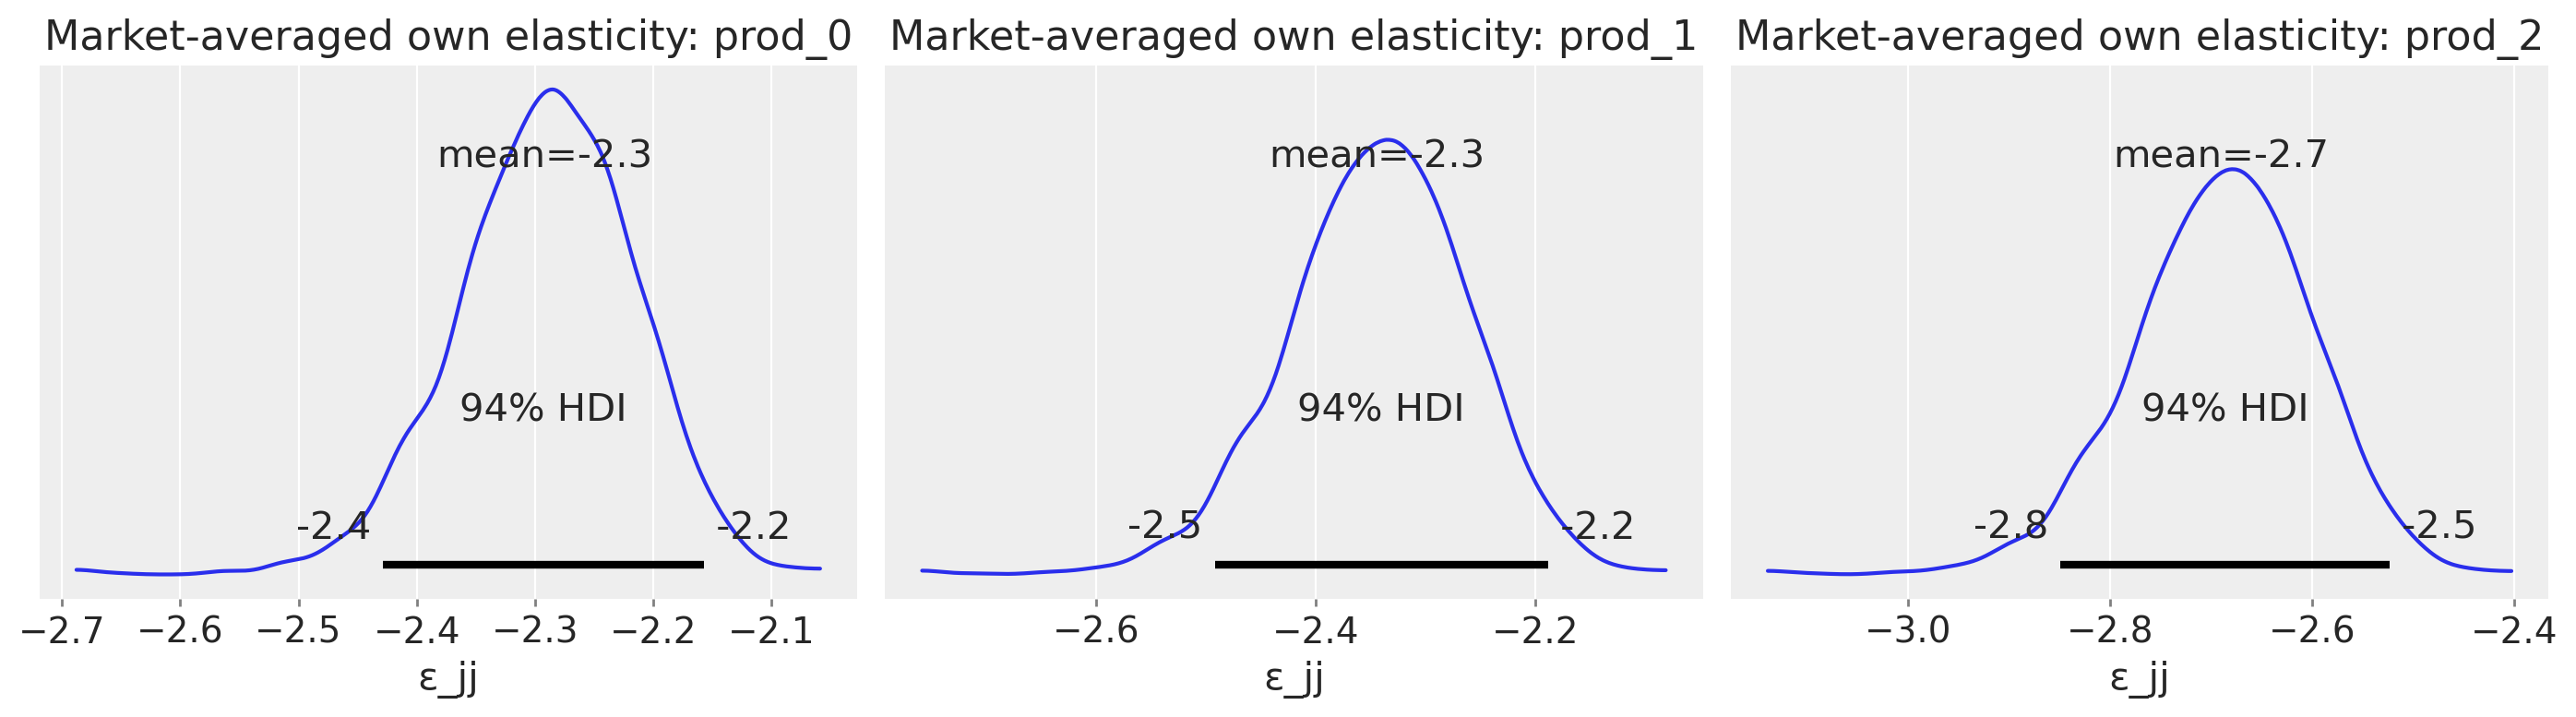

In [51]:
# Posterior distribution of own-price elasticity for the first product
elast = model.elasticities(at="mean", n_samples=2000)  # was 300
elast_samples = model.elasticities(at="samples", n_samples=2000)  # was 300

fig, axs = plt.subplots(1, model._J, figsize=(14, 4), sharey=True)
for j, (ax, pname) in enumerate(zip(axs, model._inside_products, strict=True)):
    # Average across markets per posterior sample → smooth 1D posterior
    own_avg = elast_samples.values[:, :, j, j].mean(axis=1)  # (sample,)
    az.plot_posterior({"own_ε": own_avg}, var_names=["own_ε"], ax=ax)
    ax.set_title(f"Market-averaged own elasticity: {pname}")
    ax.set_xlabel("ε_jj")
plt.tight_layout()

### Per-market variation in own-price elasticity

Averaging across markets hides genuine *cross-market* heterogeneity: the same product can be more elastic in markets where its baseline share is small or its realised price is high. The forest plot below shows the per-market 94 % HDI of `prod_0`'s own-price elasticity — one row per market — using the full posterior.

The horizontal spread of the interval *centres* is the structural across-market variation that the market-averaged plot collapsed; the *width* of each interval is per-market posterior uncertainty (typically wider in markets with sparse shares or extreme prices).


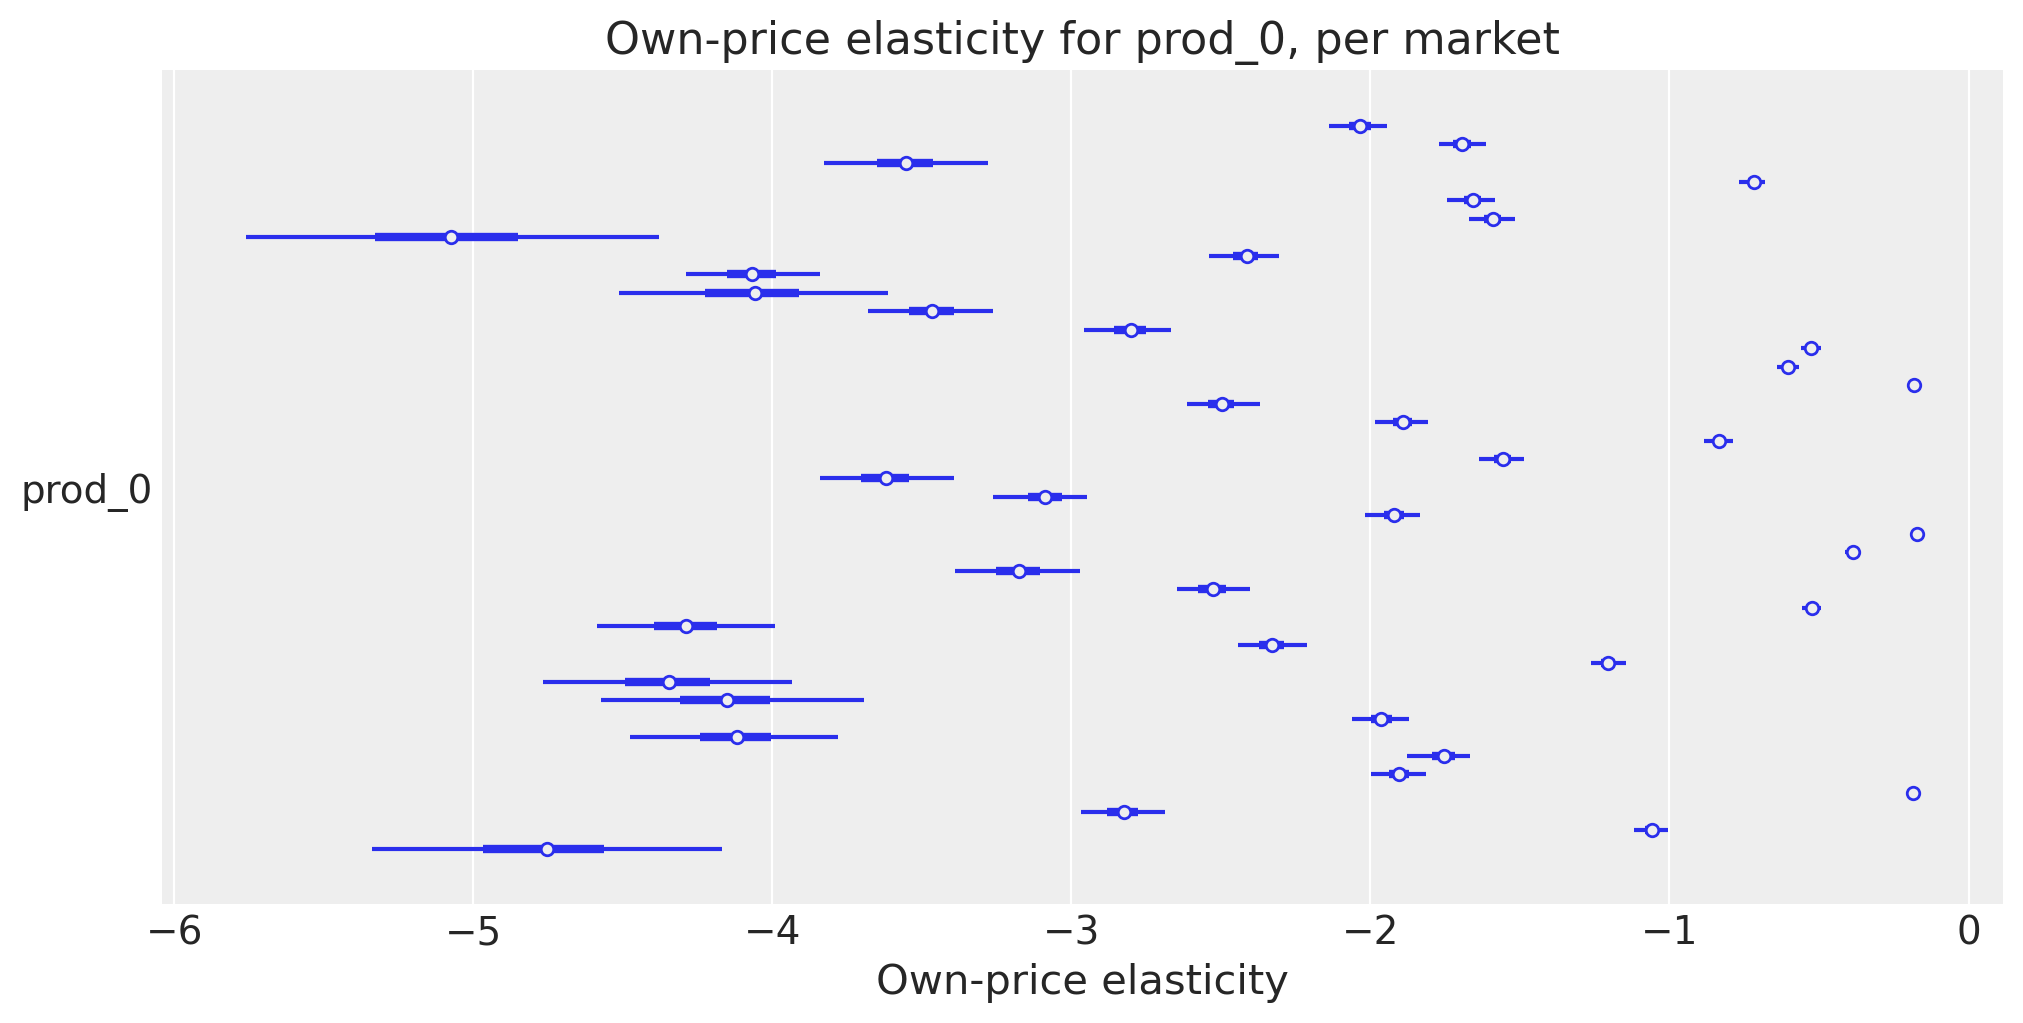

In [77]:
fig, ax = plt.subplots(figsize=(10, 5))
own = elast_samples.values[:, :, 0, 0]  # (sample, market) for prod_0
az.plot_forest(
    {"prod_0": own.T},  # (market, sample)
    combined=False,
    ax=ax,
)
ax.set_xlabel("Own-price elasticity")
ax.set_title("Own-price elasticity for prod_0, per market");

## 7. Counterfactual pricing

`counterfactual_shares(price_change=...)` holds the latent demand shock ξ_jt constant (read directly from the posterior) and re-evaluates the share equation at new prices. This is the structurally correct counterfactual: it asks *given the same unobserved market conditions*, what would market shares be at the new prices?

We examine a **10 % price hike on the first product**:
- its own share should fall (consumers substitute away)
- rival shares and the outside good should rise


In [56]:
target_product = model._inside_products[0]
print(f"Applying 10% price hike to: {target_product}")

baseline_cf = model.counterfactual_shares(price_change=None, n_samples=300)
shocked_cf = model.counterfactual_shares(
    price_change={target_product: 0.10}, n_samples=300
)

baseline_s = baseline_cf["s_inside"].mean(dim="sample").values  # (M, J)
shocked_s = shocked_cf["s_inside"].mean(dim="sample").values
delta_s = shocked_s - baseline_s  # share change

baseline_s_out = baseline_cf["s_outside"].mean(dim="sample").values  # (M,)
shocked_s_out = shocked_cf["s_outside"].mean(dim="sample").values

print("\nMarket-average share changes after 10% price hike on", target_product)
print("-" * 55)
for j, pname in enumerate(model._inside_products):
    b = baseline_s[:, j].mean()
    s = shocked_s[:, j].mean()
    print(f"  {pname:<12}  baseline={b:.4f}  shocked={s:.4f}  Δ={s - b:+.4f}")
print(
    f"  {'outside':<12}  baseline={baseline_s_out.mean():.4f}  "
    f"shocked={shocked_s_out.mean():.4f}  "
    f"Δ={shocked_s_out.mean() - baseline_s_out.mean():+.4f}"
)

Applying 10% price hike to: prod_0

Market-average share changes after 10% price hike on prod_0
-------------------------------------------------------
  prod_0        baseline=0.1066  shocked=0.0962  Δ=-0.0105
  prod_1        baseline=0.1419  shocked=0.1433  Δ=+0.0013
  prod_2        baseline=0.0850  shocked=0.0860  Δ=+0.0011
  outside       baseline=0.6664  shocked=0.6745  Δ=+0.0081


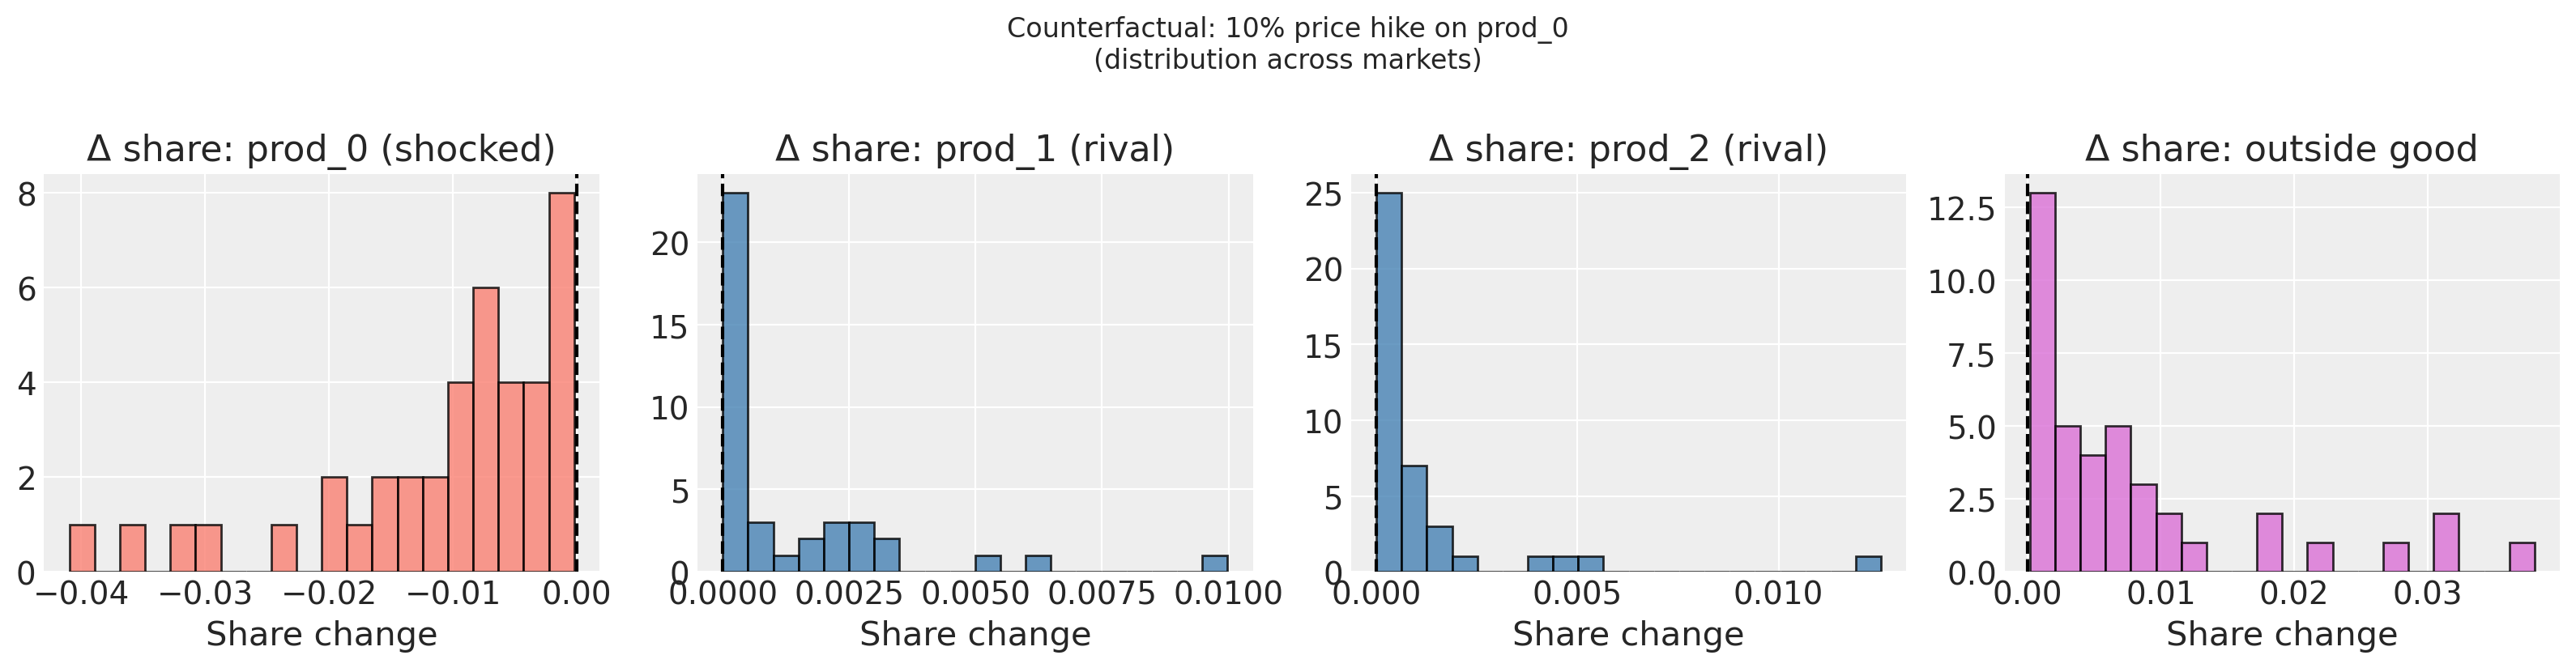

In [57]:
# Visualise share-change distributions across markets
fig, axs = plt.subplots(1, model._J + 1, figsize=(16, 4))

for j, (ax, pname) in enumerate(zip(axs[:-1], model._inside_products, strict=True)):
    colour = "salmon" if pname == target_product else "steelblue"
    ax.hist(delta_s[:, j], bins=20, color=colour, alpha=0.8, edgecolor="k")
    ax.axvline(0, color="k", lw=1.5, ls="--")
    ax.set_title(
        f"Δ share: {pname}" + (" (shocked)" if pname == target_product else " (rival)")
    )
    ax.set_xlabel("Share change")

delta_out = shocked_s_out - baseline_s_out
axs[-1].hist(delta_out, bins=20, color="orchid", alpha=0.8, edgecolor="k")
axs[-1].axvline(0, color="k", lw=1.5, ls="--")
axs[-1].set_title("Δ share: outside good")
axs[-1].set_xlabel("Share change")

plt.suptitle(
    f"Counterfactual: 10% price hike on {target_product}\n"
    "(distribution across markets)",
    y=1.02,
)
plt.tight_layout()
plt.show()

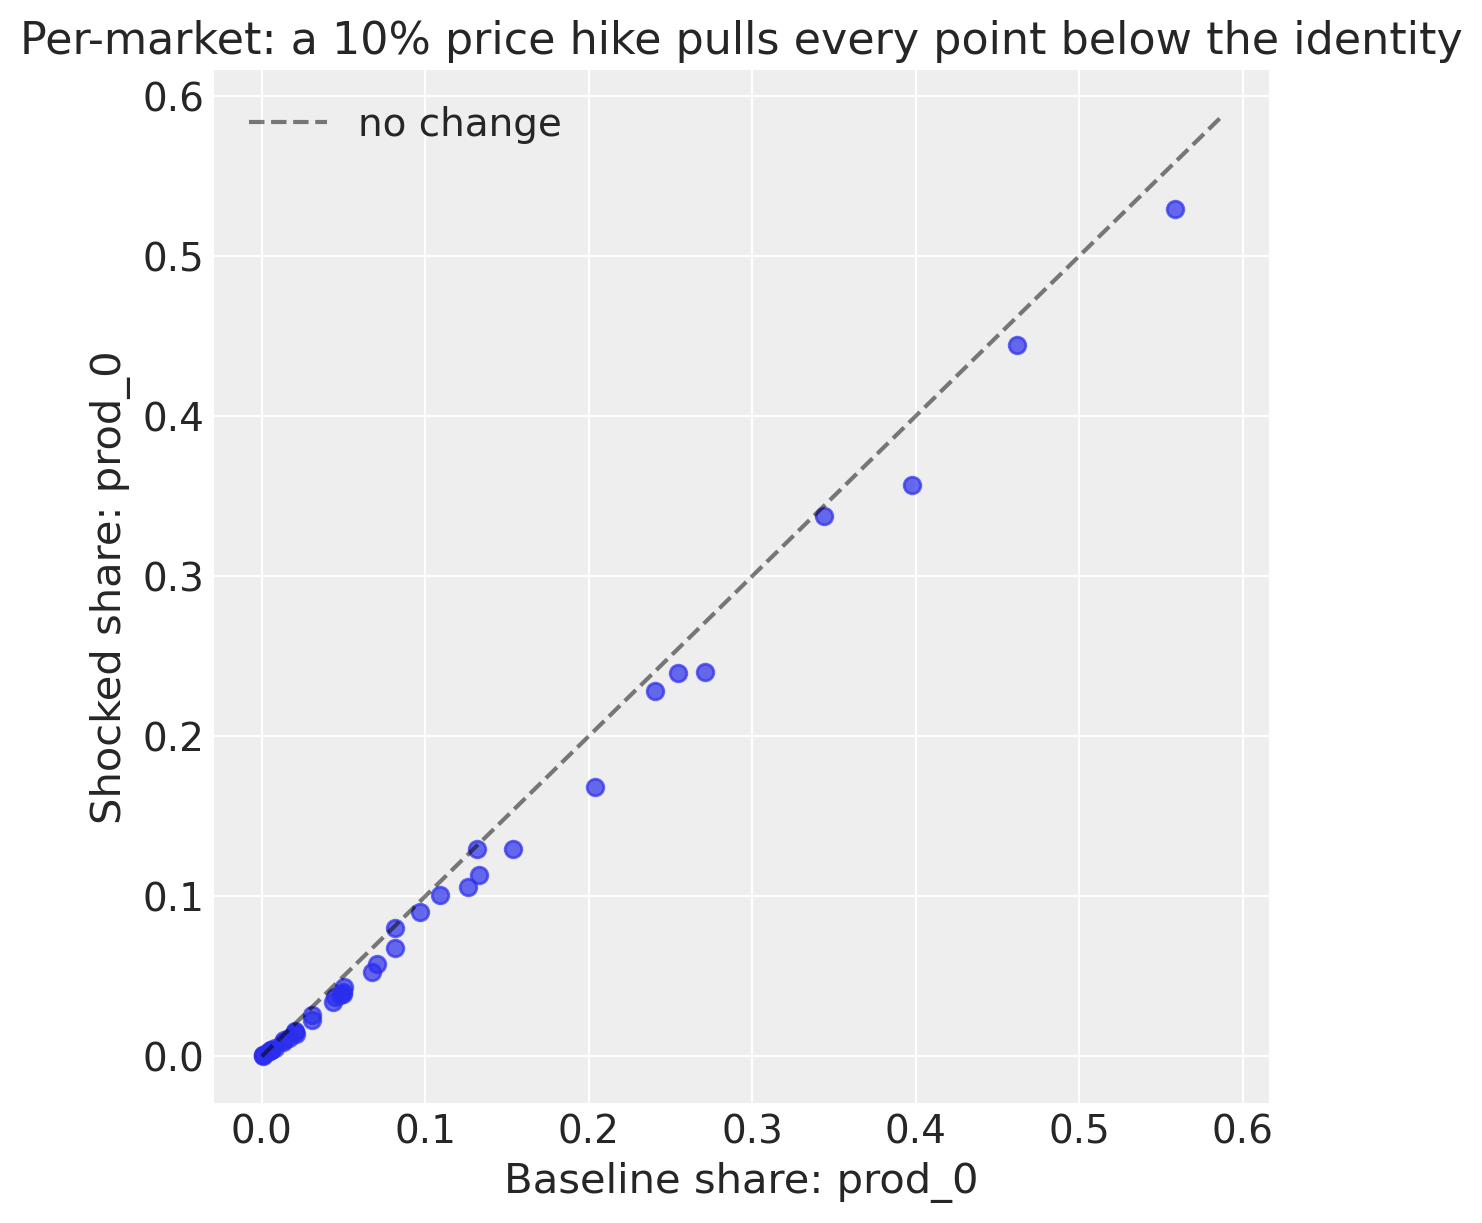

In [58]:
own_idx = model._inside_products.index(target_product)

fig, ax = plt.subplots(figsize=(6, 6))
b = baseline_cf["s_inside"].mean(dim="sample").values[:, own_idx]
s = shocked_cf["s_inside"].mean(dim="sample").values[:, own_idx]
ax.scatter(b, s, alpha=0.7)
lim = max(b.max(), s.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", alpha=0.5, label="no change")
ax.set_xlabel(f"Baseline share: {target_product}")
ax.set_ylabel(f"Shocked share: {target_product}")
ax.set_title("Per-market: a 10% price hike pulls every point below the identity")
ax.legend()

Text(0.5, 1.0, 'Per-market Δshare from 10% price hike on prod_0')

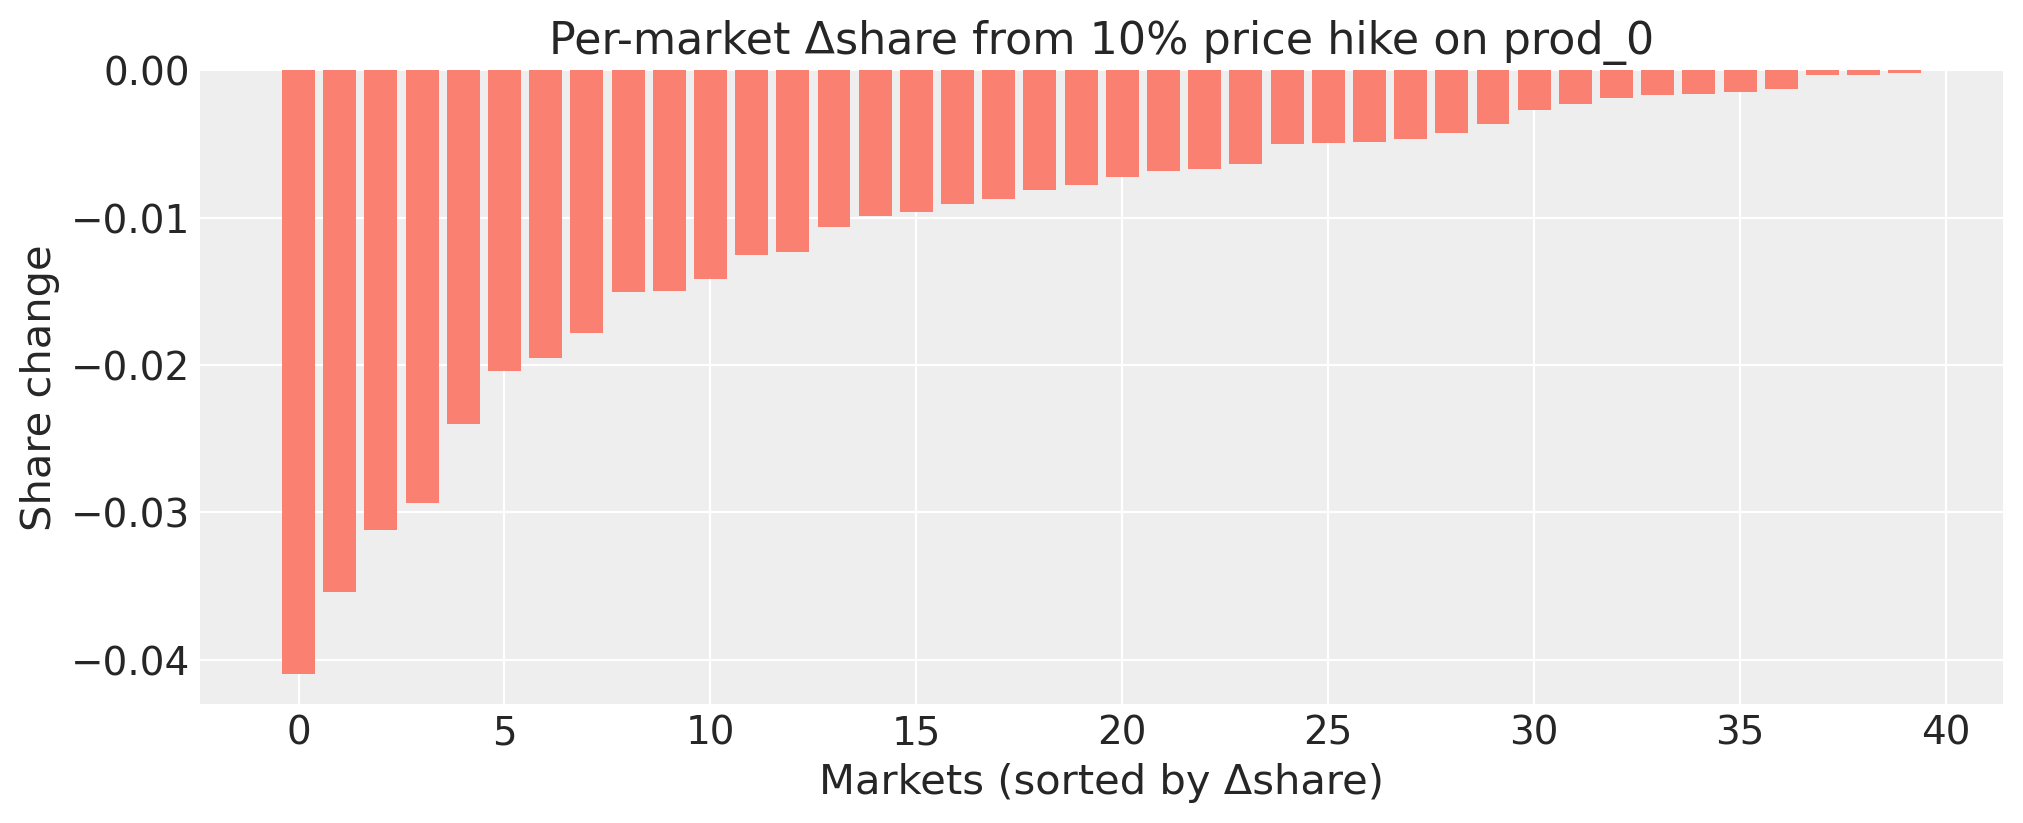

In [59]:
delta = (
    (shocked_cf["s_inside"] - baseline_cf["s_inside"])
    .mean(dim="sample")
    .values[:, own_idx]
)
order = np.argsort(delta)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(delta)), delta[order], color="salmon")
ax.set_xlabel("Markets (sorted by Δshare)")
ax.set_ylabel("Share change")
ax.set_title(f"Per-market Δshare from 10% price hike on {target_product}")

### Time-targeted counterfactuals

Because we constructed the model with `time_col="period"`, the counterfactual API accepts `periods=` and `regions=` coord-label arguments. Use them to scope an intervention to a specific time window or geography rather than applying it across the whole panel.

The cell below applies the same 10% price hike on `prod_0` *only* in periods 10–20. Outside that window the counterfactual shares are bit-identical to the baseline (no intervention there); inside the window they coincide with the full-panel counterfactual.


Outside the window: max |Δ vs baseline| = 0.0
Inside the window:  max |Δ vs full-panel cf| = 0.02814192804821622


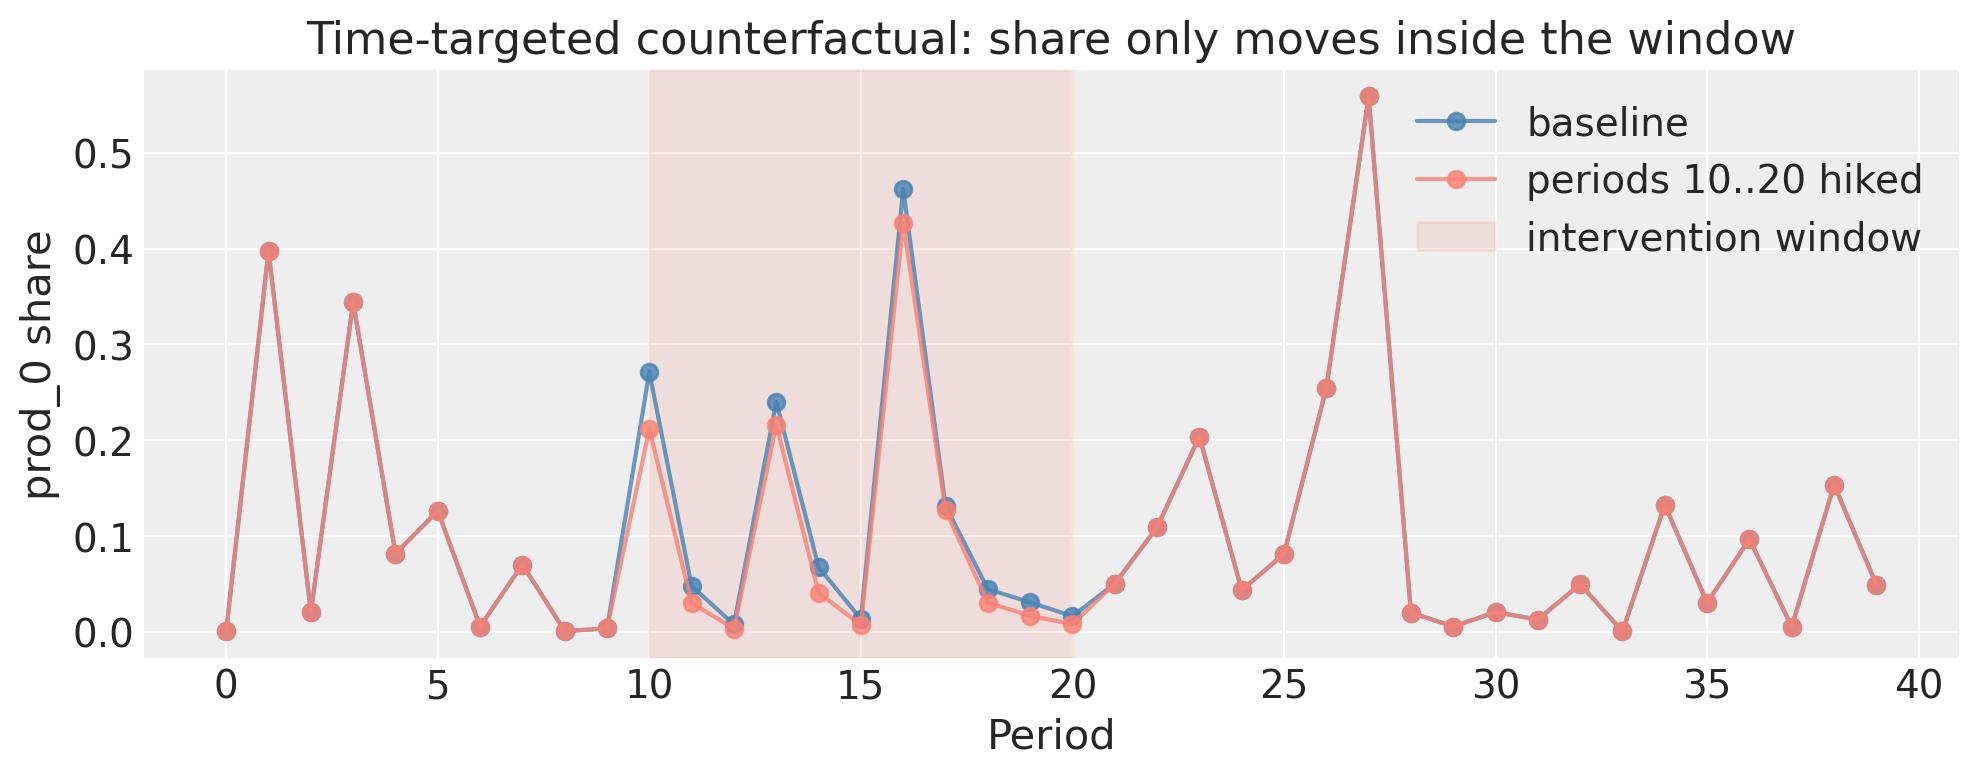

In [60]:
# Apply the 10% hike only in periods 10..20 (inclusive)
window = list(range(10, 21))
cf_window = model.counterfactual_shares(
    price_change={target_product: 0.20},
    periods=window,
    n_samples=300,
)

# The returned dataset carries period+region as non-dim coords on `market`,
# so we can verify the masking directly with xarray.
period_coord = cf_window.coords["period"].values
in_window = np.isin(period_coord, window)

baseline_inside = baseline_cf["s_inside"].mean(dim="sample").values[:, own_idx]
shocked_window_inside = cf_window["s_inside"].mean(dim="sample").values[:, own_idx]
shocked_full_inside = shocked_cf["s_inside"].mean(dim="sample").values[:, own_idx]

print(
    "Outside the window: max |Δ vs baseline| =",
    np.abs(shocked_window_inside[~in_window] - baseline_inside[~in_window]).max(),
)
print(
    "Inside the window:  max |Δ vs full-panel cf| =",
    np.abs(shocked_window_inside[in_window] - shocked_full_inside[in_window]).max(),
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    period_coord, baseline_inside, "o-", color="steelblue", label="baseline", alpha=0.8
)
ax.plot(
    period_coord,
    shocked_window_inside,
    "o-",
    color="salmon",
    label="periods 10..20 hiked",
    alpha=0.8,
)
ax.axvspan(10, 20, color="salmon", alpha=0.15, label="intervention window")
ax.set_xlabel("Period")
ax.set_ylabel(f"{target_product} share")
ax.set_title("Time-targeted counterfactual: share only moves inside the window")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Hierarchical pooling across regions

When markets belong to distinct geographic regions, `region_col` activates partial pooling across regions:

```
α_pop ~ N(0, 2)    τ_α ~ HalfNormal(1)
α_r   = α_pop + τ_α · α_r_raw        α_r_raw ~ N(0, 1)
```

This is the headline differentiator vs GMM BLP: thin markets are shrunk toward the population mean, giving stable inference without discarding data.

We generate a 3-region panel with genuine region-level preference heterogeneity (`region_heterogeneity=0.6`) and verify that `τ_α` (the between-region SD) has posterior mass away from zero.


In [61]:
df_multi, truth_multi = generate_blp_panel(
    T=20,
    J=3,
    K=2,
    L=2,
    R_geo=3,
    region_heterogeneity=0.6,
    true_alpha=-2.0,
    sigma_alpha=0.5,
    instrument_strength=0.7,
    price_xi_corr=0.5,
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=7,
    return_truth=True,
)

print("Regions:", df_multi["region"].unique())
print("Markets per region:", df_multi.groupby("region")["market"].nunique().to_dict())
print("True per-region alpha_r:", np.round(truth_multi["alpha_r"], 3))

Regions: ['r0' 'r1' 'r2']
Markets per region: {'r0': 20, 'r1': 20, 'r2': 20}
True per-region alpha_r: [-1.999 -1.821 -2.164]


In [62]:
model_hier = BayesianBLP(
    market_data=df_multi,
    characteristics=truth_multi["characteristic_cols"],
    instruments=truth_multi["instrument_cols"],
    region_col="region",
    random_coef_on=["price"],
    n_mc_draws=100,
    random_seed=0,
    hierarchical_parameterisation="centered",
)
model_hier.fit(**_FIT_KWARGS)
n_div_hier = int(model_hier.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div_hier}")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.08,63
,2000,0,0.07,63
,2000,0,0.08,127
,2000,0,0.07,127


Divergences: 0


In [63]:
az.summary(
    model_hier.idata,
    var_names=["alpha_pop", "tau_alpha", "alpha_r"],
    round_to=2,
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_pop,-1.88,0.30,-2.35,-1.33,0.01,0.03,876.51,897.12,1.00
tau_alpha,0.36,0.30,0.06,0.90,0.01,0.01,1724.64,1550.53,1.00
alpha_r[r0],-1.94,0.06,-2.07,-1.83,0.00,0.00,205.23,430.42,1.01
alpha_r[r1],-1.78,0.06,-1.90,-1.66,0.00,0.00,213.74,460.44,1.01
alpha_r[r2],-2.09,0.06,-2.21,-1.97,0.00,0.00,211.33,401.09,1.01


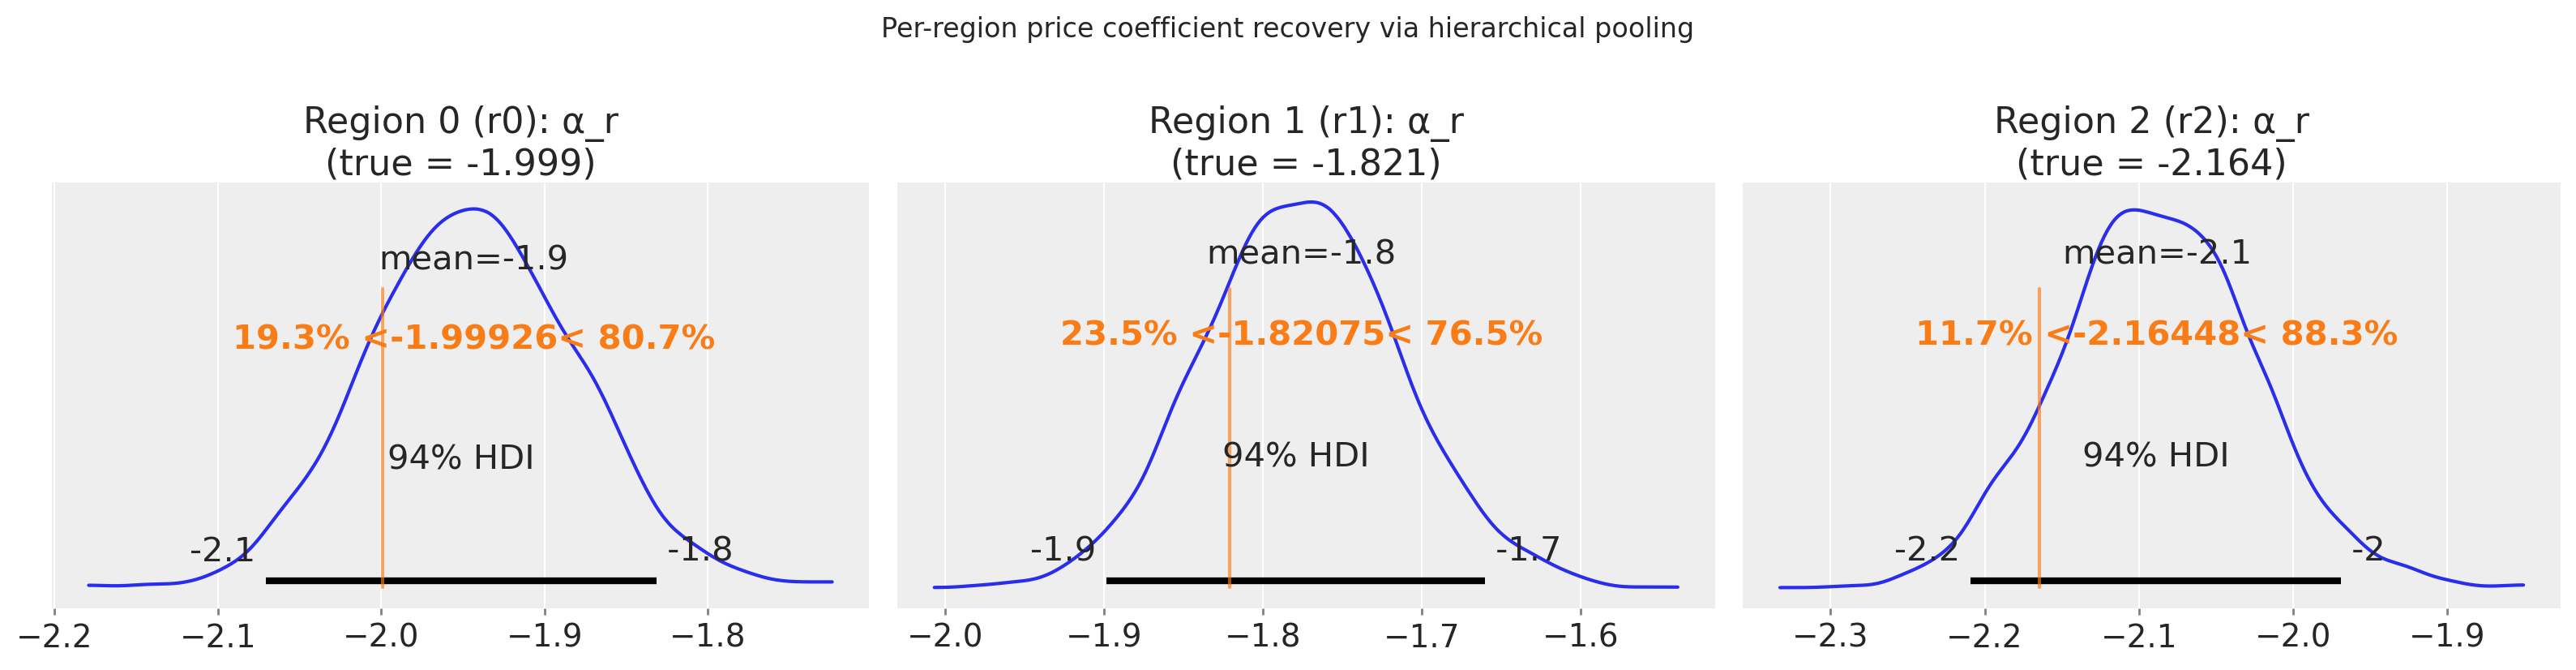

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

# Match the model's region ordering exactly
region_labels = (
    model_hier._regions
)  # or list(model_hier.idata.posterior.coords["region"].values)

for r, (ax, region_label, true_val) in enumerate(
    zip(axs, region_labels, truth_multi["alpha_r"], strict=True)
):
    az.plot_posterior(
        model_hier.idata,
        var_names=["alpha_r"],
        coords={"region": region_label},
        ref_val=float(true_val),
        ax=ax,
    )
    ax.set_title(f"Region {r} ({region_label}): α_r\n(true = {true_val:.3f})")

plt.suptitle("Per-region price coefficient recovery via hierarchical pooling", y=1.02)
plt.tight_layout()
plt.show()

In [65]:
# tau_alpha: between-region SD should be > 0 under genuine heterogeneity
tau_lo, tau_hi = az.hdi(
    model_hier.idata.posterior["tau_alpha"].values.ravel(), hdi_prob=0.94
)
print(f"tau_alpha 94% HDI: [{tau_lo:.3f}, {tau_hi:.3f}]")
print("tau_alpha lower bound > 0:", tau_lo > 0)

tau_alpha 94% HDI: [0.058, 0.900]
tau_alpha lower bound > 0: True


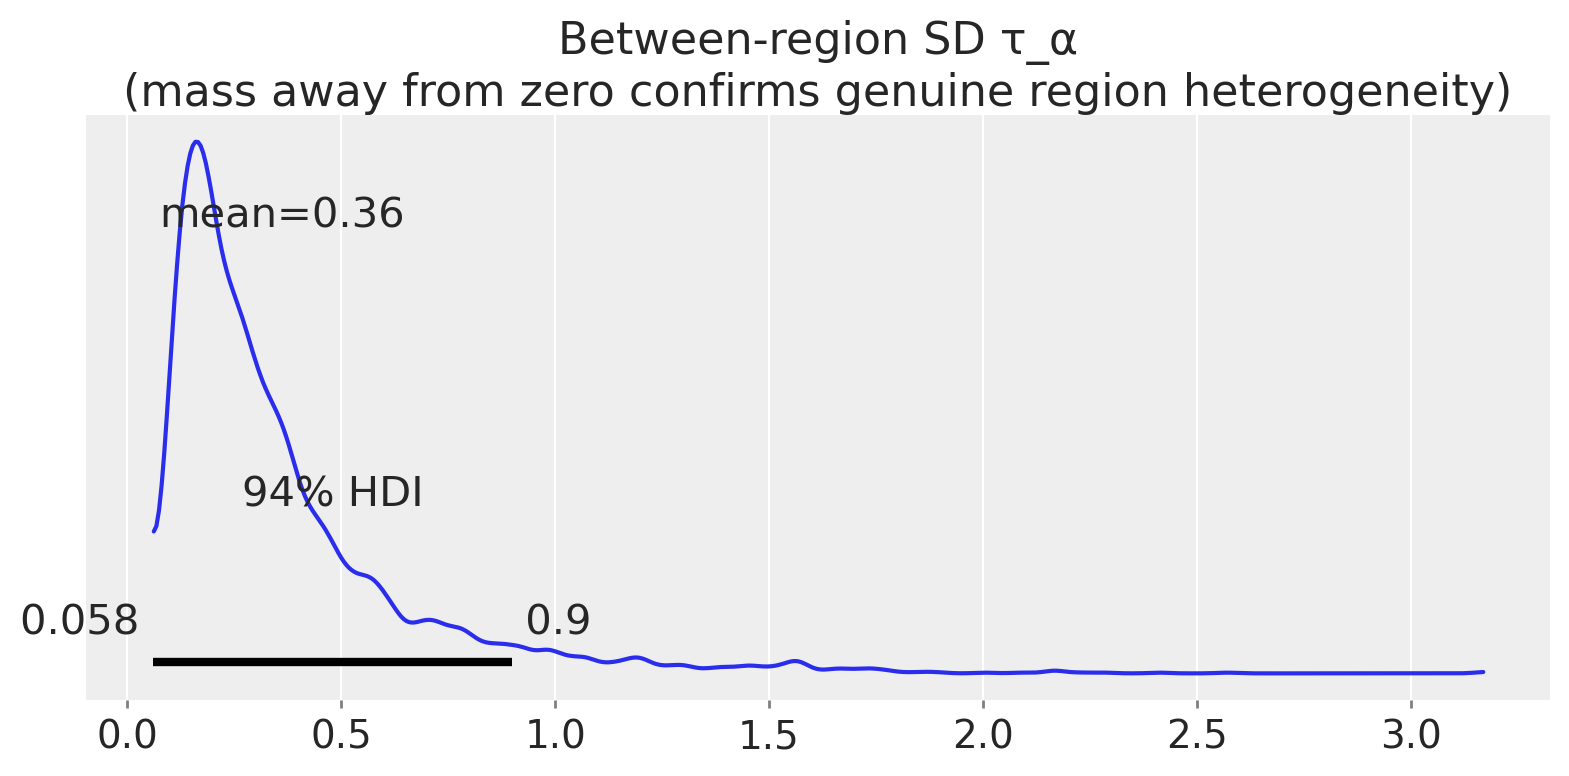

In [66]:
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_posterior(model_hier.idata, var_names=["tau_alpha"], ax=ax)
ax.set_title(
    "Between-region SD τ_α\n(mass away from zero confirms genuine region heterogeneity)"
)
plt.tight_layout()
plt.show()

## Interpreting the Taste Profiles

The model integrates over a population of consumer taste types to predict aggregate market shares. Having fit the posterior, we can reverse the question: **which taste types does each market rely on to generate its observed shares?** This is Bayesian backward inference — from aggregate patterns to latent consumer heterogeneity.

Each Halton draw represents one taste type with price sensitivity $\alpha + \sigma \nu_r$, where $\nu_r < 0$ means *more* price-sensitive and $\nu_r > 0$ means *less* price-sensitive. The stacked area charts below show how each type allocates across products as we sweep from the most price-sensitive consumers (left) to the least (right).


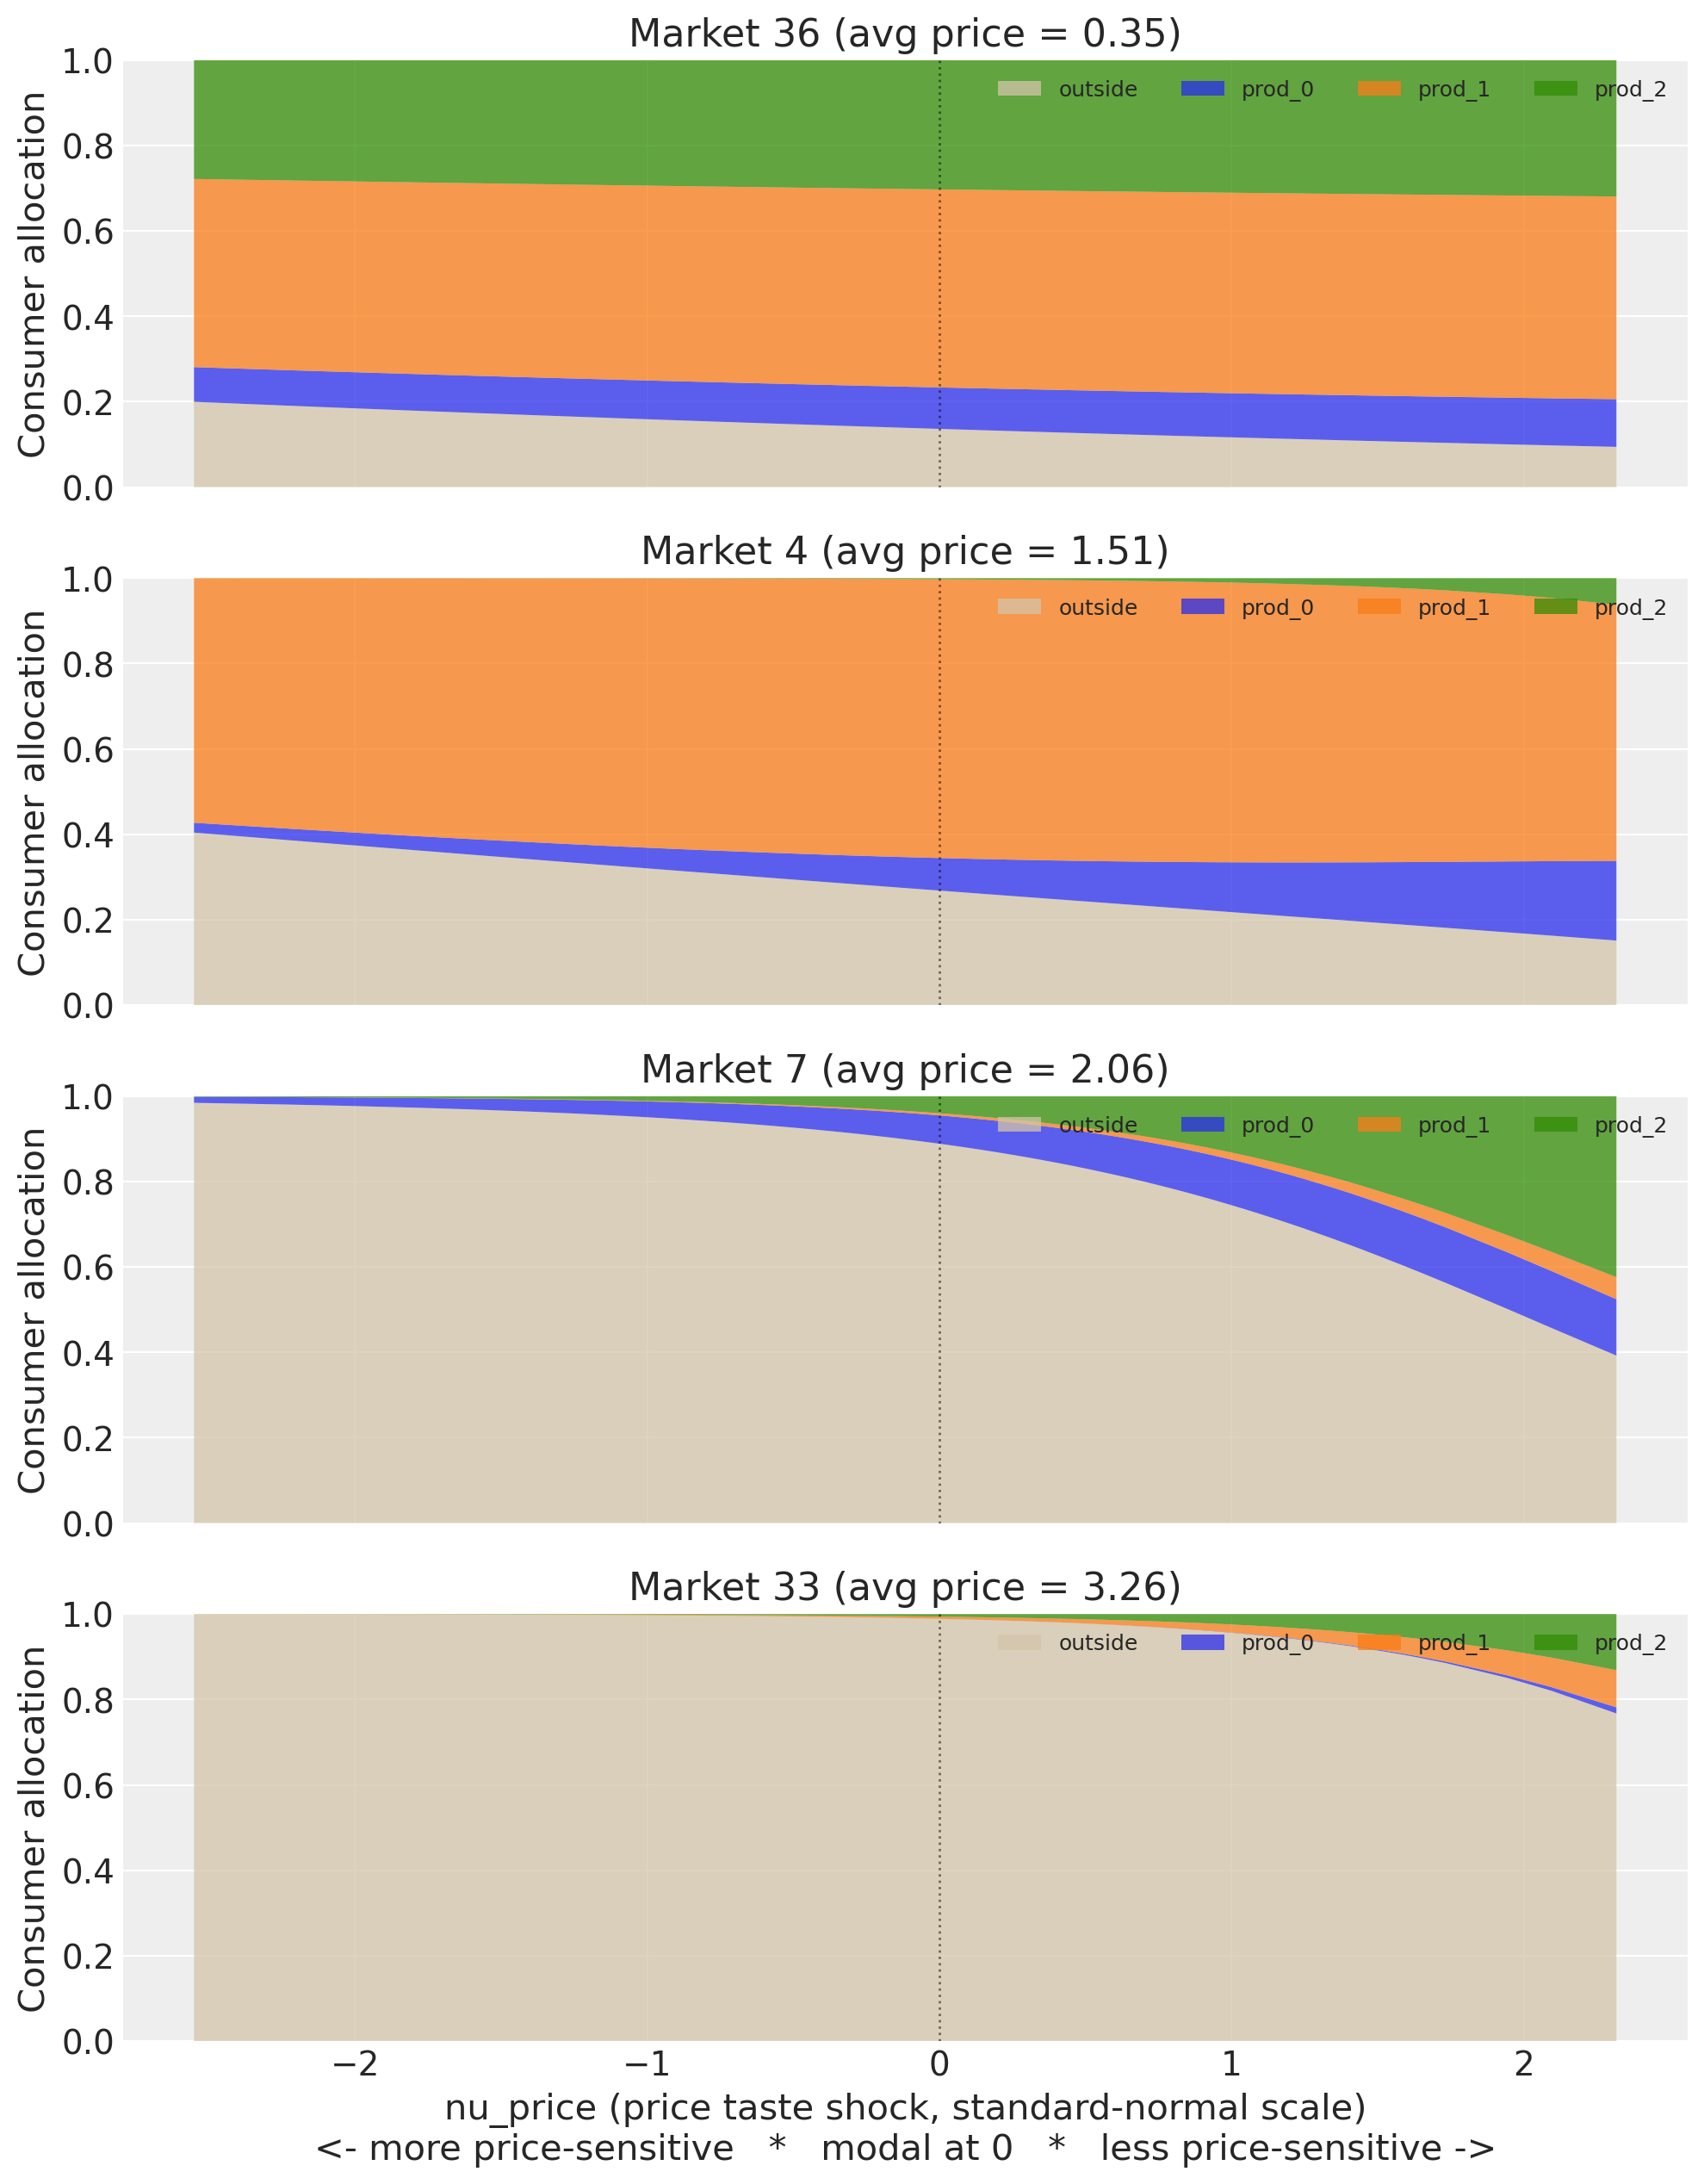

In [92]:
def plot_taste_profile_stacked(model, market_indices=None, n_samples=200):
    """Stacked area chart of consumer allocation across the nu_price axis.

    The outside good sits at the bottom; inside products are stacked above.
    Reading left to right: as nu increases (less price-sensitive), the outside
    band shrinks and the inside-product bands grow. Market-to-market differences
    in the transition shape reflect price-level and characteristic differences.
    """
    if market_indices is None:
        market_indices = list(range(min(4, model._M)))

    # Draw `n_samples` sets of (alpha, beta, xi, sigma) from the fitted posterior.
    # Each set defines a complete parameterisation of the demand model.
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)

    # For each posterior draw, compute every Halton consumer's per-product
    # choice probability. Returns:
    #   s_per_draw    : (S, M, J, R) — choice prob per sample, market, product, consumer type
    #   s_out_per_draw: (S, M, R)    — outside-good prob per sample, market, consumer type
    s_per_draw, _, s_out_per_draw, *_ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )

    # Average over posterior draws to get the expected allocation per consumer type.
    s_avg = s_per_draw.mean(axis=0)  # (M, J, R)
    s_out_avg = s_out_per_draw.mean(axis=0)  # (M, R)

    # The price taste shock for each Halton draw (already standard-normal).
    # nu < 0 = more price-sensitive, nu > 0 = less price-sensitive.
    nu = model._halton[: model.n_mc_draws, 0]
    order = np.argsort(nu)
    nu_sorted = nu[order]

    n = len(market_indices)
    _fig, axes = plt.subplots(n, 1, figsize=(10, 3.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    outside_color = "#d4c5a9"
    inside_colors = prop_cycle[: model._J]

    for ax, m_idx in zip(axes, market_indices, strict=True):
        stacks = [
            s_out_avg[m_idx, order],
            *[s_avg[m_idx, j, order] for j in range(model._J)],
        ]
        labels = ["outside", *model._inside_products]
        colors = [outside_color, *inside_colors]
        ax.stackplot(
            nu_sorted, *stacks, labels=labels, colors=colors, alpha=0.75, zorder=1
        )

        ax.axvline(0, color="black", linestyle=":", lw=1, alpha=0.5)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Consumer allocation")
        avg_p = float(model._price[m_idx].mean())
        ax.set_title(f"Market {model._markets[m_idx]} (avg price = {avg_p:.2f})")
        ax.legend(loc="upper right", ncol=model._J + 1, fontsize=9, framealpha=0.9)

    axes[-1].set_xlabel(
        "nu_price (price taste shock, standard-normal scale)\n"
        "<- more price-sensitive   *   modal at 0   *   less price-sensitive ->"
    )
    plt.tight_layout()
    plt.show()


# Span the price range: cheapest / low-mid / high-mid / most expensive
_avg_p = model._price.mean(axis=1)
_order = np.argsort(_avg_p)
_picks = [
    int(_order[0]),
    int(_order[len(_order) // 3]),
    int(_order[2 * len(_order) // 3]),
    int(_order[-1]),
]
plot_taste_profile_stacked(model, market_indices=_picks)

### Reading the results

**Market 36 (avg price 0.35) — price doesn't matter here.** The allocation bands are nearly flat across the entire ν axis. Even the most price-sensitive consumers (left edge) still buy inside goods — the outside good (grey) stays thin throughout. When everything costs 35 cents, the price coefficient has nothing to bite on. Product choice is driven almost entirely by characteristics: prod_1 (orange) dominates, prod_2 (green) is second, prod_0 (blue) is a sliver. A flat logit without random coefficients would fit this market nearly as well.

**Market 4 (avg price 1.51) — heterogeneity starts to bite.** The outside good grows noticeably on the left (price-sensitive types are starting to exit), but the transition is gradual. Prod_1 still dominates inside demand. The inside/outside split at ν = 0 (the modal consumer) is roughly 60/40 — most consumers still participate. The slope from left to right tells you σ_random is doing real work here: different taste types make meaningfully different choices.

**Market 7 (avg price 2.06) — the cliff.** At ν < 0 the market is almost entirely outside good — price-sensitive consumers have left. The inside products only emerge for ν > 0, and now prod_2 (green) overtakes prod_1 (orange) as the winner among insensitive types. This is the product-switching effect: prod_2 apparently has better non-price characteristics, but you can only see that once price sensitivity stops masking it. The modal consumer (ν = 0) allocates ~95% to outside — this is a niche category at this price level.

**Market 33 (avg price 3.26) — luxury niche.** The outside good fills nearly the entire chart until ν > ~1.5 (roughly the top 7% of the price-insensitivity distribution). Only the most extreme insensitive types buy inside goods at all, and even they split narrowly between prod_2 and prod_1. This market's inside demand is almost entirely carried by a thin tail of the taste distribution — the demand-share table would show ~60%+ insensitive contribution against a 16% population baseline.

**The cross-market story in one sentence:** as average price rises from 0.35 to 3.26, the stacked area transforms from a flat rectangle (homogeneous, characteristics-driven) to a step function (only the insensitive tail participates) — and the identity of the winning inside product flips from prod_1 to prod_2 along the way.

In [93]:
import pandas as pd


def taste_type_demand_share(model, n_samples=200):
    """Share of inside-good demand contributed by each taste-type bucket.

    Buckets by the price taste shock nu (already standard-normal):
      - price-sensitive:   nu < -1  (~16%% of population)
      - modal:            -1 <= nu <= 1  (~68%%)
      - price-insensitive: nu > 1   (~16%%)

    Under a homogeneous logit (sigma=0) every bucket would contribute in
    proportion to its population share: 16 / 68 / 16.  Deviations from
    that baseline reveal where heterogeneity matters.
    """
    # Draw posterior parameter sets, then compute per-consumer-type choice probs
    # (same mechanics as the stacked area chart above).
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)
    s_per_draw, _, _, _, _ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )

    # Collapse to (M, R): average over posterior draws AND products,
    # giving total inside-good demand per consumer type per market.
    s_avg = s_per_draw.mean(axis=(0, 2))  # (M, R)

    # Price taste shock per Halton draw (standard-normal; nu<0 = price-sensitive)
    nu = model._halton[: model.n_mc_draws, 0]
    sensitive = nu < -1.0
    insensitive = nu > 1.0
    modal = ~sensitive & ~insensitive

    rows = []
    for m in range(model._M):
        total = s_avg[m].sum()
        rows.append(
            {
                "market": model._markets[m],
                "avg_price": float(model._price[m].mean()),
                "sensitive_pct": s_avg[m, sensitive].sum() / total,
                "modal_pct": s_avg[m, modal].sum() / total,
                "insensitive_pct": s_avg[m, insensitive].sum() / total,
            }
        )
    return pd.DataFrame(rows)


profiles = taste_type_demand_share(model, n_samples=200)

# Baseline: under a flat logit the buckets contribute proportionally
nu = model._halton[: model.n_mc_draws, 0]
baseline = {
    "sensitive": (nu < -1).mean(),
    "modal": ((nu >= -1) & (nu <= 1)).mean(),
    "insensitive": (nu > 1).mean(),
}

print("Share of inside-good demand by taste-type bucket:\n")
print(profiles.to_string(index=False, float_format=lambda x: f"{x:6.3f}"))
print(f"\nHomogeneous baseline: {baseline}")

Share of inside-good demand by taste-type bucket:

 market  avg_price  sensitive_pct  modal_pct  insensitive_pct
      0      2.441          0.040      0.563            0.397
      1      2.078          0.093      0.673            0.235
      2      1.601          0.101      0.676            0.224
      3      0.993          0.151      0.676            0.172
      4      1.509          0.143      0.681            0.177
      5      1.358          0.111      0.690            0.199
      6      2.929          0.004      0.309            0.686
      7      2.064          0.038      0.562            0.401
      8      2.092          0.089      0.652            0.259
      9      2.510          0.024      0.523            0.453
     10      1.231          0.086      0.664            0.250
     11      1.602          0.113      0.640            0.247
     12      2.508          0.059      0.653            0.287
     13      1.064          0.145      0.680            0.174
     14      1.992 

## 10. Summary

In this notebook we demonstrated the full BayesianBLP workflow:

1. **Data generation** — `generate_blp_panel` with endogenous prices and known truth.
2. **Prior predictive check** — shares sum to 1; priors cover plausible scanner data.
3. **IV fit** — zero divergences; posterior recovers `α`, `β`, `σ_α` inside the 94% HDI.
4. **Endogeneity bias** — dropping instruments biases `α` toward zero by `≈0.16`;
   instruments correct this.
5. **Elasticities** — own-price negative (−3 to −5 range); cross-price positive;
   full posterior uncertainty available.
6. **Counterfactual** — a 10% price hike on one product reduces its share,
   raises rivals and the outside good, with calibrated posterior uncertainty.
7. **Price sensitivity** — implied taste profiles per market


In [94]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Sun May 03 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

pymc_marketing: 0.19.3

pymc_marketing: 0.19.3
seaborn       : 0.13.2
pandas        : 2.3.3
scipy         : 1.16.3
xarray        : 2025.12.0
arviz         : 0.23.0
numpy         : 2.3.5
matplotlib    : 3.10.8

Watermark: 2.5.0

